# Benchmark de Técnicas para Extração Automática de Emoções em Relatos Diários
## Computação Afetiva - Projeto de Análise Emocional em Texto (Português Europeu)

### Introdução

#### Contexto do Projeto
Este notebook insere-se num projeto de Computação Afetiva cujo objetivo é desenvolver um sistema capaz de identificar automaticamente a emoção predominante em relatos diários de 30 a 60 segundos, transcritos a partir de áudio. O sistema final será uma aplicação onde os utilizadores gravam um breve resumo do seu dia, e o sistema classifica a emoção segundo o modelo de Ekman, com uma classe adicional `neutral`.

#### Modelo de Ekman
Paul Ekman identificou seis emoções básicas universais, reconhecidas transculturalmente:
- **Alegria (Joy)**: Caracterizada por bem-estar, satisfação, entusiasmo
- **Tristeza (Sadness)**: Associada a perda, desânimo, melancolia
- **Surpresa (Surprise)**: Reação a eventos inesperados, espanto
- **Raiva (Anger)**: Frustração, irritação, revolta
- **Nojo (Disgust)**: Aversão, repulsa, desconforto
- **Medo (Fear)**: Ansiedade, preocupação, insegurança

Adicionámos a classe **Neutral** para capturar relatos sem dominância emocional clara, padrão em muitos contextos quotidianos.

#### Porquê uma Distribuição de Confiança?
Em vez de apenas uma etiqueta discreta, o sistema prevê uma distribuição de probabilidade para todas as sete emoções. Isto é crucial porque:
- Emoções raramente são puras - podem coexistir
- Ajuda a quantificar a incerteza do modelo
- Permite decisões mais informadas (ex: pedir clarificação se confiança for baixa)
- Facilita ensembles e pós-processamento

#### Porquê Comparar Múltiplas Técnicas?
Diferentes abordagens têm vantagens distintas:
- **Baselines léxicas**: Simples e interpretáveis, mas ignoram contexto
- **Zero-shot NLI**: Multilingue, sem necessidade de treino, mas computacionalmente pesado
- **Modelos fine-tuned**: Alta precisão se bem treinados, mas sensíveis ao domínio
- **Embeddings semânticos**: Capturam significado, mas requerem protótipos bem definidos
- **LLMs**: Flexíveis e contextualmente ricos, mas exigem recursos e podem ser instáveis

#### Este Benchmark
Com 50 relatos cuidadosamente anotados em português europeu, este benchmark permite uma comparação inicial robusta entre 8-10 técnicas distintas. Embora limitado, é significativamente mais informativo do que testes com poucos exemplos. A decisão final considerará não apenas a accuracy, mas também:
- Top-2 accuracy (emoção correta entre as duas mais prováveis)
- Confiança média na emoção correta
- Rank médio da etiqueta correta
- Entropia das distribuições
- Robustez, custo computacional e facilidade de integração

## 1. Instalação e Imports

In [1]:
# Instalação de dependências necessárias (executar apenas se não estiverem instaladas)
import subprocess
import sys

required_packages = [
    'transformers',
    'torch',
    'pandas',
    'numpy',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'tqdm',
    'sentence-transformers',
    'requests',
    'accelerate',
    'sentencepiece',
    'protobuf',
    'scipy'
]

def install_package(package):
    try:
        __import__(package.replace('-', '_'))
    except ImportError:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

for package in required_packages:
    install_package(package)

print("\n✅ Dependências instaladas/verificadas com sucesso!")

Instalando scikit-learn...
Instalando protobuf...

✅ Dependências instaladas/verificadas com sucesso!


In [2]:
# Imports principais
import json
import re
import warnings
from collections import defaultdict, Counter
from typing import Dict, List, Tuple, Optional, Any
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.special import softmax
from scipy.stats import entropy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Transformers e modelos
import torch
from transformers import (
    pipeline, 
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    AutoModel,
    AutoModelForSeq2SeqLM,
    M2M100ForConditionalGeneration,
    M2M100Tokenizer
)
from sentence_transformers import SentenceTransformer, util

# Configurações
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Detectar GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Device disponível: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memória total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("   ⚠️  GPU não disponível - alguns modelos pesados podem ser lentos")

🔧 Device disponível: cuda
   GPU: Tesla T4
   Memória total: 15.64 GB


## 2. Dataset de 50 Relatos em Português Europeu

In [3]:
# Dataset com 50 relatos anotados manualmente
EMOTIONS = ["joy", "sadness", "surprise", "anger", "disgust", "fear", "neutral"]

dataset = [
    # JOY (7 relatos)
    {"id": "R001", "text": "Hoje foi daqueles dias em que tudo parece encaixar. O sol estava radiante quando acordei, preparei um pequeno-almoço especial e até consegui terminar aquele projeto que me estava a dar dores de cabeça. À tarde, encontrei uns amigos no parque e rimos tanto que me doíam as bochechas. Sinto-me mesmo leve e grata pela vida.", "true_label": "joy"},
    {"id": "R002", "text": "Acordei com energia renovada, coisa que não me acontecia há semanas. Fui dar uma corrida à beira-rio e o cheiro da maresia fez-me tão bem. No trabalho recebi um elogio do chefe que me deixou radiante. Ao jantar, a minha irmã surpreendeu-me com a minha sobremesa favorita. Sabe tão bem quando os dias correm assim.", "true_label": "joy"},
    {"id": "R003", "text": "A minha equipa conseguiu fechar aquele negócio difícil. Andávamos nisto há meses e finalmente deu frutos. A sensação de alívio e orgulho é indescritível. Fomos celebrar com um brinde e até o gerente veio dar os parabéns. É gratificante ver o esforço reconhecido.", "true_label": "joy"},
    {"id": "R004", "text": "Passei a tarde com a minha avó e foi tão especial. Ela ensinou-me a fazer a receita secreta dela, aquela que o meu avô adorava. A casa encheu-se com aquele cheiro aconchegante e rimo-nos tanto quando ela me contou histórias da juventude. Guardei cada momento no coração.", "true_label": "joy"},
    {"id": "R005", "text": "Finalmente consegui aquela vaga no curso que tanto queria. Quando abri o email fiquei aos saltos pela sala, nem conseguia acreditar. Liguei logo à minha mãe e ela começou a chorar de felicidade. É daqueles dias que marcam uma vida, parece que tudo vai dar certo.", "true_label": "joy"},
    {"id": "R006", "text": "Hoje fiz voluntariado no canil e foi das experiências mais gratificantes. Passei a manhã a dar banho e a brincar com cães que precisam de carinho. Vi um deles a ser adotado por uma família tão querida, e a alegria do bichano era contagiante. Sai de lá com o coração cheio.", "true_label": "joy"},
    {"id": "R007", "text": "Recebi uma carta da minha melhor amiga que emigrou. Saber que ela está feliz e que se lembra de mim fez-me um bem danado. Pus-me a reler as nossas mensagens antigas e dei por mim a sorrir sozinha. A amizade verdadeira ultrapassa qualquer distância.", "true_label": "joy"},
    
    # SADNESS (7 relatos)
    {"id": "R008", "text": "Hoje foi pesado. Acordei sem vontade de sair da cama, com aquela sensação de cansaço que não passa. No trabalho nada correu bem, só levava com críticas. Ao chegar a casa encontro uma conta inesperada que me deixou ainda mais amargo. Parece que nada tem graça, sabe?", "true_label": "sadness"},
    {"id": "R009", "text": "Senti-me tão sozinho hoje. Andei pela cidade e via as pessoas aos pares, a rir, a conversar. Entrei num café onde costumava ir com a Maria e o dono perguntou por ela. Tive que inventar uma desculpa qualquer, doeu ter de mentir.", "true_label": "sadness"},
    {"id": "R010", "text": "A minha cadela já está mesmo velhota, mal se mexe. Hoje esteve deitada a tarde toda sem querer comer. Fiquei ali ao pé dela a fazer-lhe festas e a lembrar-me de quando era cachopa e corria atrás de mim. O coração apertou de uma forma...", "true_label": "sadness"},
    {"id": "R011", "text": "Chorei no carro a caminho do trabalho. Não sei explicar bem, é uma tristeza que vem do nada. Sinto que perdi o prazer nas coisas que antes me animavam. Até ouvir a minha música favorita me soube a pouco. Dias assim são difíceis de aguentar.", "true_label": "sadness"},
    {"id": "R012", "text": "Descobri que não fui selecionado para a promoção. Deram o lugar a um colega que entrou depois de mim. Sinto-me injustiçado e desvalorizado, como se todo o meu esforço não tivesse servido de nada. O pior é ter que continuar a trabalhar ao lado dele.", "true_label": "sadness"},
    {"id": "R013", "text": "Hoje fui ao funeral de um amigo de infância. Ver os pais dele ali desfeitos foi de partir o coração. Lembrei-me de todos os momentos, das brincadeiras na rua, do primeiro dia de escola. Apercebi-me de como o tempo passa e de como perdemos pessoas sem aviso.", "true_label": "sadness"},
    {"id": "R014", "text": "Sinto que o meu casamento está a desmoronar. Jantámos em silêncio, cada um no seu telemóvel. Tentei puxar conversa, mas ela respondeu com monossílabos. Lembro-me de como éramos no início e pergunto-me onde é que falhámos.", "true_label": "sadness"},
    
    # SURPRISE (7 relatos)
    {"id": "R015", "text": "Não estava mesmo à espera! A meio da tarde bateram à porta e era uma encomenda. Quando abro, era aquele livro que queria há meses e que estava esgotado em todo o lado. A minha namorada arranjou uma edição especial usada e ofereceu-mo assim, sem mais nem menos. Fiquei de boca aberta!", "true_label": "surprise"},
    {"id": "R016", "text": "Fui ao médico para uns exames de rotina e recebi a notícia de que estou grávida. Não planeávamos, foi totalmente inesperado. Saí da consulta a tremer, a tentar processar. Nunca imaginei ouvir isto assim, de repente. Ainda estou em choque.", "true_label": "surprise"},
    {"id": "R017", "text": "Estava no escritório quando de repente apagam as luzes e começam a cantar os parabéns. Tinha-me esquecido completamente do meu aniversário. Os meus colegas prepararam um bolo e tudo. Fiquei sem reação, nem sabia o que dizer. Nunca pensei que se lembrassem.", "true_label": "surprise"},
    {"id": "R018", "text": "Vi alguém que julgava estar no estrangeiro. Estava a fazer compras no supermercado quando ouço a voz dele. Era o meu primo, que supostamente estava na Austrália. Apanhou-me mesmo desprevenida, dei um pulo e quase deixei cair o cabaz.", "true_label": "surprise"},
    {"id": "R019", "text": "Recebi uma carta do banco a dizer que me foi aprovado um crédito habitação. Andava há meses a tentar e já tinha perdido a esperança. Até achei que era um engano, tive que ler três vezes para acreditar. A vida dá mesmo umas voltas.", "true_label": "surprise"},
    {"id": "R020", "text": "O meu chefe chamou-me à sala e pensei logo que era para me despedir. Na verdade, ofereceu-me uma semana de férias extra como recompensa por ter batido as metas. Fiquei estupefacto, nem respondi logo. Demorou uns segundos a processar.", "true_label": "surprise"},
    {"id": "R021", "text": "Estava a ver o telejornal e de repente aparece o meu prédio nas imagens. Um incêndio num andar abaixo do meu. Não senti cheiro a fumo nem ouvi alarmes. Liguei logo para casa, ninguém atendia. Nunca corri tão rápido na vida.", "true_label": "surprise"},
    
    # ANGER (7 relatos)
    {"id": "R022", "text": "Estou mesmo furioso. Alguém riscou o meu carro estacionado e bazou sem deixar nada. Tive que pagar do bolso um arranjo que nem sequer era minha culpa. Ainda por cima o seguro não cobre. Este tipo de falta de respeito deixa-me aos saltos.", "true_label": "anger"},
    {"id": "R023", "text": "O meu colega de trabalho apropriou-se do meu projeto. Apresentou-o como se fosse dele, nem mencionou o meu nome. Quando o confrontei, ainda se fez de vítima. Nunca me senti tão traído. Passei o resto do dia a ferver por dentro.", "true_label": "anger"},
    {"id": "R024", "text": "Atendimento ao cliente de uma operadora, nem me façam falar. Estive uma hora à espera, fui reencaminhado para quatro departamentos diferentes e no fim não resolveram nada. Quando pedi para falar com o supervisor, desligaram-me na cara. É de uma falta de profissionalismo!", "true_label": "anger"},
    {"id": "R025", "text": "Discuti feio com o meu inquilino hoje. Ele decidiu que ia pagar só metade da renda porque 'teve despesas extra'. Mas contrato é contrato. Ainda me chamou de exploradora. Nunca me senti tão desrespeitada na minha própria casa.", "true_label": "anger"},
    {"id": "R026", "text": "Estava no trânsito e um gajo ultrapassou pela direita, quase me bateu e ainda me fez um gesto obsceno. A adrenalina subiu logo, comecei a suar frio. Tive que me controlar para não sair do carro e ir atrás dele. Esta gente não tem noção.", "true_label": "anger"},
    {"id": "R027", "text": "Votei hoje e foi um caos. As filas eram enormes, as mesas de voto mal organizadas. Os funcionários pareciam perdidos, ninguém sabia de nada. Esperei quase três horas para votar. Isto num país democrático é um escândalo.", "true_label": "anger"},
    {"id": "R028", "text": "Pedi comida de takeaway, veio frio e com metade dos ingredientes em falta. Quando reclamei, disseram que era 'culpa do estafeta'. Não me devolveram o dinheiro nem ofereceram solução. Pagar para ser mal servido é uma roubalheira.", "true_label": "anger"},
    
    # DISGUST (7 relatos)
    {"id": "R029", "text": "Fui ao supermercado e vi um tipo a tossir para a mão e depois a tocar nas frutas. A sério, há pessoas sem noção. Fiquei com tanto nojo que não consegui comprar nada. Ainda por cima estamos em época de gripes. É de uma falta de civismo.", "true_label": "disgust"},
    {"id": "R030", "text": "Abri o frigorífico e tinha um cheiro nauseabundo. Uma embalagem de carne que se estragou e escorria um líquido asqueroso. Demorei uma hora a limpar aquilo, tive que usar luvas e máscara. Quase vomitei para dentro três vezes.", "true_label": "disgust"},
    {"id": "R031", "text": "Ouvi uma conversa no comboio tão nojenta. Um tipo a gabar-se de como enganava os clientes no negócio dele. Ria-se de pessoas idosas que ele convenceu a comprar coisas inúteis. A falta de ética e de compaixão deixou-me enjoado.", "true_label": "disgust"},
    {"id": "R032", "text": "Estava a comer um croissant quando sinto uma textura estranha. Olho e tinha um cabelo enorme no meio. Pus logo aquilo de lado, perdi a fome completamente. Ainda reclamei na pastelaria e a senhora disse 'acontece'. Só não pedi o livro de reclamações porque estava com pressa.", "true_label": "disgust"},
    {"id": "R033", "text": "O vizinho do lado deixou o lixo no patamar comum durante dias. Começou a cheirar mal e apareceram moscas. A comida podre a escorrer pelo chão. Tive que chamar o condomínio para resolver. Como é que alguém vive assim?", "true_label": "disgust"},
    {"id": "R034", "text": "Li uma notícia tão sórdida no jornal. Descobriram um esquema onde uma clínica vendia órgãos de cadáveres sem consentimento das famílias. Nem sei como há gente capaz de fazer isto por dinheiro. Fiquei com uma sensação de repulsa que não me largou o dia todo.", "true_label": "disgust"},
    {"id": "R035", "text": "Fui ao cinema e o lugar ao lado estava todo colado com pingos de doce ou sei lá o quê. A cadeira estava pegajosa, o braço também. Sentei-me de lado o filme todo para não tocar. Há pessoas que não têm o mínimo de respeito pelos outros.", "true_label": "disgust"},
    
    # FEAR (7 relatos)
    {"id": "R036", "text": "Recebi uma mensagem ameaçadora no telemóvel. Alguém que sabe onde moro, o meu horário de trabalho. Dizia coisas horríveis sobre a minha filha. Passei o dia com o coração às voltas, a olhar para trás. Não sei se vou conseguir dormir.", "true_label": "fear"},
    {"id": "R037", "text": "Tive que fazer uma apresentação para toda a empresa hoje. Já há dias que não dormia bem só de pensar. Quando entrei na sala, começou-me a tremer a voz e as mãos suavam. Senti um aperto no peito, pensei que ia desmaiar. Foi horrível.", "true_label": "fear"},
    {"id": "R038", "text": "Saí tarde do trabalho e estava escuro. Ouvi passos atrás de mim, sempre a acelerar quando eu acelerava. A rua estava deserta. Comecei a imaginar o pior, entrei no primeiro café que vi aberto. Só saí quando pedi um Uber. Nunca tive tanto medo.", "true_label": "fear"},
    {"id": "R039", "text": "Os resultados dos exames médicos demoraram a chegar. Cada minuto parecia uma hora. Fui à casa de banho umas dez vezes só de nervoso. Quando o médico ligou, as mãos tremiam tanto que quase deixei cair o telemóvel. Ainda bem que afinal não era nada grave.", "true_label": "fear"},
    {"id": "R040", "text": "Sonhei que me perseguiam ontem à noite. Acordei às três da manhã aos gritos, encharcada em suor. Não consegui voltar a dormir, fiquei com os olhos abertos no escuro, com medo de fechar e voltar ao mesmo pesadelo. Hoje estou exausta e assustada.", "true_label": "fear"},
    {"id": "R041", "text": "Ouvi um barulho estranho em casa à meia-noite. Tinha a certeza que era alguém a forçar a fechadura. Peguei num guarda-chuva como arma e fui vér. Não havia ninguém, mas o coração batia tão forte que doía. Demorei horas a acalmar.", "true_label": "fear"},
    {"id": "R042", "text": "A minha empresa anunciou despedimentos coletivos. Ninguém sabe quem vai sair. Passei o dia numa ansiedade terrível, a olhar para o email a cada dois minutos. O ambiente está pesado, ninguém fala. Tenho uma família para sustentar, não sei o que faria.", "true_label": "fear"},
    
    # NEUTRAL (8 relatos)
    {"id": "R043", "text": "Hoje foi um dia normal. Acordei, tomei o pequeno-almoço, fui trabalhar. Resolvi uns emails, atendi duas reuniões, almocei no refeitório. Voltei para casa, vi um pouco de televisão e jantei. Nada de especial aconteceu, correu tudo como planeado.", "true_label": "neutral"},
    {"id": "R044", "text": "Fiz as compras da semana, como faço todas as quartas. Paguei as contas que estavam para vencer, organizei os papéis. À tarde dei uma volta para arejar. O tempo esteve nublado mas sem chuva. Um dia perfeitamente neutro, sem sobressaltos.", "true_label": "neutral"},
    {"id": "R045", "text": "Atendi vários clientes hoje no consultório. A maioria foram consultas de rotina, nada de grave. Troquei impressões com a colega do lado sobre um artigo científico. Ao final do dia, arquivei os processos e vim para casa. Rotina normal de trabalho.", "true_label": "neutral"},
    {"id": "R046", "text": "Passei o dia a fazer limpezas em casa. Aspirei, lavei a loiça, organizei o roupeiro. À tarde, fui buscar os miúdos à escola como sempre. O jantar foi sopa e o que sobrou de ontem. Não houve conflitos nem momentos especialmente bons ou maus.", "true_label": "neutral"},
    {"id": "R047", "text": "Acordei, trabalhei, almocei, continuei a trabalhar, fui ao ginásio, tomei banho, jantei, dormi. Foi um dia útil como outro qualquer. Nem demasiado cansativo nem especialmente produtivo. Apenas mais um dia a cumprir a rotina.", "true_label": "neutral"},
    {"id": "R048", "text": "Li as notícias do dia, vi alguns vídeos no YouTube, respondi a mensagens. Marquei consulta no dentista para o mês que vem. À noite, fiz uma chamada de rotina para a minha mãe. Nada de relevante ou emocionante, só o normal.", "true_label": "neutral"},
    {"id": "R049", "text": "Resolvi algumas burocracias no banco. Atualizar o cartão de cidadão, pedir uma segunda via de uma fatura. Esperei nas filas, preenchi formulários, recebi confirmações. Tarefas administrativas maçadoras mas necessárias. Mais um dia a tratar da vida.", "true_label": "neutral"},
    {"id": "R050", "text": "O dia passou sem grande história. Levantei, fui trabalhar, voltei, adormeci no sofá a ver um documentário sobre a natureza. Acordei a tempo de me deitar. Não houve acontecimentos marcantes, foi só mais um dia comum.", "true_label": "neutral"}
]

# Converter para DataFrame
df_dataset = pd.DataFrame(dataset)
print(f"📊 Dataset carregado: {len(df_dataset)} relatos")
print(f"\nDistribuição das emoções:")
print(df_dataset['true_label'].value_counts().sort_index())

# Validar distribuição
expected_counts = {'joy': 7, 'sadness': 7, 'surprise': 7, 'anger': 7, 'disgust': 7, 'fear': 7, 'neutral': 8}
print("\n✅ Validação da distribuição esperada:")
for emotion, expected in expected_counts.items():
    actual = len(df_dataset[df_dataset['true_label'] == emotion])
    status = "✓" if actual == expected else "✗"
    print(f"  {status} {emotion}: {actual} (esperado: {expected})")

# Estatísticas dos textos
df_dataset['word_count'] = df_dataset['text'].apply(lambda x: len(x.split()))
print(f"\n📏 Estatísticas dos relatos:")
print(f"  Média de palavras: {df_dataset['word_count'].mean():.1f}")
print(f"  Mínimo: {df_dataset['word_count'].min()}")
print(f"  Máximo: {df_dataset['word_count'].max()}")
print(f"  Mediana: {df_dataset['word_count'].median():.0f}")

# Mostrar alguns exemplos
print("\n📝 Exemplos de relatos por emoção:")
for emotion in EMOTIONS:
    sample = df_dataset[df_dataset['true_label'] == emotion].iloc[0]
    print(f"\n  [{emotion.upper()}] {sample['text'][:150]}...")

📊 Dataset carregado: 50 relatos

Distribuição das emoções:
true_label
anger       7
disgust     7
fear        7
joy         7
neutral     8
sadness     7
surprise    7
Name: count, dtype: int64

✅ Validação da distribuição esperada:
  ✓ joy: 7 (esperado: 7)
  ✓ sadness: 7 (esperado: 7)
  ✓ surprise: 7 (esperado: 7)
  ✓ anger: 7 (esperado: 7)
  ✓ disgust: 7 (esperado: 7)
  ✓ fear: 7 (esperado: 7)
  ✓ neutral: 8 (esperado: 8)

📏 Estatísticas dos relatos:
  Média de palavras: 42.8
  Mínimo: 34
  Máximo: 55
  Mediana: 43

📝 Exemplos de relatos por emoção:

  [JOY] Hoje foi daqueles dias em que tudo parece encaixar. O sol estava radiante quando acordei, preparei um pequeno-almoço especial e até consegui terminar ...

  [SADNESS] Hoje foi pesado. Acordei sem vontade de sair da cama, com aquela sensação de cansaço que não passa. No trabalho nada correu bem, só levava com crítica...

  [SURPRISE] Não estava mesmo à espera! A meio da tarde bateram à porta e era uma encomenda. Quando abro, era a

## 3. Funções Auxiliares Gerais

In [4]:
def softmax_normalize(scores: Dict[str, float], temperature: float = 1.0) -> Dict[str, float]:
    """
    Aplica softmax a um dicionário de scores para obter distribuição de probabilidade.
    
    Args:
        scores: Dicionário {emoção: score}
        temperature: Temperatura para suavizar (1.0 = normal; >1 mais suave; <1 mais acentuado)
    
    Returns:
        Dicionário com probabilidades normalizadas que somam 1
    """
    emotions = list(scores.keys())
    values = np.array([scores[e] for e in emotions]) / temperature
    exp_values = np.exp(values - np.max(values))  # Estabilidade numérica
    probs = exp_values / exp_values.sum()
    return {emotions[i]: float(probs[i]) for i in range(len(emotions))}


def get_predicted_label(distribution: Dict[str, float]) -> str:
    """
    Obtém a emoção prevista (a com maior probabilidade).
    
    Args:
        distribution: Dicionário com probabilidades por emoção
    
    Returns:
        Emoção com maior probabilidade
    """
    return max(distribution, key=distribution.get)


def rank_true_label(distribution: Dict[str, float], true_label: str) -> int:
    """
    Determina a posição (rank) da emoção correta no ranking ordenado.
    
    Args:
        distribution: Dicionário com probabilidades por emoção
        true_label: Emoção correta
    
    Returns:
        Posição (1-based) da emoção correta (1 = primeira posição)
    """
    sorted_emotions = sorted(distribution, key=distribution.get, reverse=True)
    return sorted_emotions.index(true_label) + 1


def top_k_contains_true_label(distribution: Dict[str, float], true_label: str, k: int = 2) -> bool:
    """
    Verifica se a emoção correta está entre as top-k emoções mais prováveis.
    
    Args:
        distribution: Dicionário com probabilidades por emoção
        true_label: Emoção correta
        k: Número de top posições a considerar
    
    Returns:
        True se a emoção correta estiver entre as top-k
    """
    sorted_emotions = sorted(distribution, key=distribution.get, reverse=True)
    return true_label in sorted_emotions[:k]


def compute_entropy(distribution: Dict[str, float]) -> float:
    """
    Calcula a entropia da distribuição de probabilidade.
    Valores altos indicam incerteza/indecisão.
    
    Args:
        distribution: Dicionário com probabilidades por emoção
    
    Returns:
        Entropia (base e)
    """
    probs = np.array(list(distribution.values()))
    return entropy(probs)


def margin_top1_top2(distribution: Dict[str, float]) -> float:
    """
    Diferença entre a primeira e segunda emoções mais prováveis.
    Margens grandes indicam maior confiança.
    
    Args:
        distribution: Dicionário com probabilidades por emoção
    
    Returns:
        Diferença entre top1 e top2
    """
    sorted_probs = sorted(distribution.values(), reverse=True)
    if len(sorted_probs) >= 2:
        return sorted_probs[0] - sorted_probs[1]
    return sorted_probs[0]


def validate_distribution(distribution: Dict[str, float], emotions: List[str]) -> Dict[str, float]:
    """
    Valida e corrige uma distribuição de probabilidade.
    
    Args:
        distribution: Distribuição a validar
        emotions: Lista de emoções esperadas
    
    Returns:
        Distribuição validada e normalizada
    """
    # Garantir que todas as emoções estão presentes
    for emotion in emotions:
        if emotion not in distribution:
            distribution[emotion] = 0.0
    
    # Garantir que não há probabilidades negativas
    for emotion in emotions:
        distribution[emotion] = max(0.0, distribution[emotion])
    
    # Normalizar se necessário
    total = sum(distribution.values())
    if total > 0:
        for emotion in emotions:
            distribution[emotion] /= total
    else:
        # Distribuição uniforme se todos forem zero
        for emotion in emotions:
            distribution[emotion] = 1.0 / len(emotions)
    
    return distribution


def evaluate_predictions(results_df: pd.DataFrame) -> Dict[str, Any]:
    """
    Avalia as previsões de um modelo.
    
    Args:
        results_df: DataFrame com colunas 'true_label', 'predicted_label', 'confidence_correct_label', etc.
    
    Returns:
        Dicionário com métricas de avaliação
    """
    metrics = {
        'accuracy': accuracy_score(results_df['true_label'], results_df['predicted_label']),
        'top_2_accuracy': results_df['top_2_correct'].mean(),
        'mean_confidence_correct': results_df['confidence_correct_label'].mean(),
        'mean_rank_true': results_df['true_label_rank'].mean(),
        'mean_entropy': results_df['entropy'].mean(),
        'mean_margin': results_df['margin_top1_top2'].mean(),
        'correct_predictions': results_df['correct'].sum(),
        'total_predictions': len(results_df)
    }
    return metrics


def safe_model_name(name: str) -> str:
    """Gera um nome seguro para o modelo (sem caracteres especiais)."""
    return re.sub(r'[^a-zA-Z0-9_]', '_', name)


def plot_confusion_matrix(results_df: pd.DataFrame, model_name: str, emotions: List[str]):
    """
    Plota a matriz de confusão para um modelo específico.
    
    Args:
        results_df: DataFrame com resultados
        model_name: Nome do modelo a visualizar
        emotions: Lista de emoções
    """
    model_results = results_df[results_df['model'] == model_name]
    cm = confusion_matrix(model_results['true_label'], model_results['predicted_label'], labels=emotions)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=emotions, yticklabels=emotions)
    plt.title(f'Matriz de Confusão - {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('Real', fontsize=12)
    plt.xlabel('Previsto', fontsize=12)
    plt.tight_layout()
    plt.show()

## 4. Técnica A: Baseline Lexical Simples

In [5]:
def lexical_baseline_simple(text: str) -> Dict[str, float]:
    """
    Baseline lexical simples baseada em contagem de palavras-chave.
    Assume-se fraca intencionalmente para demonstrar limitações.
    
    Args:
        text: Texto do relato
    
    Returns:
        Distribuição de probabilidade para as 7 emoções
    """
    # Palavras-chave por emoção (português europeu)
    keywords = {
        'joy': ['feliz', 'alegria', 'content', 'satisfeit', 'bem', 'ótimo', 'excelente', 'maravilh', 'ador', 'gost', 'risonh', 'sorris', 'radiante', 'energia', 'gratidão', 'orgulho', 'festa', 'celebr'],
        'sadness': ['triste', 'tristeza', 'deprimid', 'chor', 'lágrima', 'desanim', 'cansad', 'sozinho', 'solidão', 'pesado', 'morrer', 'perda', 'saudade', 'desgosto', 'melancol'],
        'surprise': ['surpres', 'inesperad', 'repente', 'espanto', 'choque', 'não acredit', 'nunca pensei', 'inesperado', 'subit', 'susto', 'estupefact'],
        'anger': ['raiva', 'furios', 'ódio', 'revolt', 'irrit', 'frustr', 'indign', 'discuss', 'briga', 'injustiç', 'traiç', 'desrespeit', 'escândal'],
        'disgust': ['nojo', 'repulsa', 'nojento', 'asqueros', 'nojoo', 'enjoad', 'podre', 'sujo', 'repugn', 'imundice', 'asno', 'porc'],
        'fear': ['medo', 'ansiedad', 'preocup', 'receio', 'pânico', 'terror', 'assust', 'apreens', 'nervos', 'insegur', 'ameaç', 'perigo', 'trem'],
        'neutral': ['normal', 'rotina', 'habitual', 'comum', 'regular', 'quotidiano', 'diant', 'mais um dia']
    }
    
    # Contar ocorrências
    text_lower = text.lower()
    scores = defaultdict(float)
    
    for emotion, words in keywords.items():
        for word in words:
            scores[emotion] += text_lower.count(word)
    
    # Normalizar para distribuição
    return softmax_normalize(dict(scores))


# Aplicar ao dataset
results_lexical_simple = []
print("🔄 A aplicar Baseline Lexical Simples...")

for idx, row in tqdm(df_dataset.iterrows(), total=len(df_dataset), desc="Processando"):
    dist = lexical_baseline_simple(row['text'])
    pred_label = get_predicted_label(dist)
    
    results_lexical_simple.append({
        'model': 'Lexical_Simple_Baseline',
        'id': row['id'],
        'true_label': row['true_label'],
        'predicted_label': pred_label,
        'correct': pred_label == row['true_label'],
        'top_2_correct': top_k_contains_true_label(dist, row['true_label'], k=2),
        'true_label_rank': rank_true_label(dist, row['true_label']),
        'confidence_correct_label': dist.get(row['true_label'], 0.0),
        **dist,
        'entropy': compute_entropy(dist),
        'margin_top1_top2': margin_top1_top2(dist)
    })

df_lexical_simple = pd.DataFrame(results_lexical_simple)
metrics_lexical_simple = evaluate_predictions(df_lexical_simple)

print(f"\n✅ Baseline Lexical Simples concluída. Accuracy: {metrics_lexical_simple['accuracy']:.2%}")
print(f"   Top-2 Accuracy: {metrics_lexical_simple['top_2_accuracy']:.2%}")

🔄 A aplicar Baseline Lexical Simples...


Processando: 100%|██████████| 50/50 [00:00<00:00, 1749.61it/s]


✅ Baseline Lexical Simples concluída. Accuracy: 54.00%
   Top-2 Accuracy: 74.00%


## 5. Técnica B: Baseline Lexical Melhorada com Negação e Intensificadores

In [7]:
def lexical_baseline_enhanced(text: str) -> Dict[str, float]:
    """
    Baseline lexical melhorada que considera negações, intensificadores e atenuadores.
    
    Args:
        text: Texto do relato
    
    Returns:
        Distribuição de probabilidade para as 7 emoções
    """
    # Palavras-chave por emoção
    keywords = {
        'joy': ['feliz', 'alegria', 'content', 'satisfeit', 'bem', 'ótimo', 'excelente', 'maravilh', 'ador', 'gost', 'risonh', 'sorris', 'radiante', 'energia', 'gratidão', 'orgulho', 'festa', 'celebr', 'amo', 'adoro'],
        'sadness': ['triste', 'tristeza', 'deprimid', 'chor', 'lágrima', 'desanim', 'cansad', 'sozinho', 'solidão', 'pesado', 'morrer', 'perda', 'saudade', 'desgosto', 'melancol', 'desol', 'abatid'],
        'surprise': ['surpres', 'inesperad', 'repente', 'espanto', 'choque', 'não acredit', 'nunca pensei', 'inesperado', 'subit', 'susto', 'estupefact'],
        'anger': ['raiva', 'furios', 'ódio', 'revolt', 'irrit', 'frustr', 'indign', 'discuss', 'briga', 'injustiç', 'traiç', 'desrespeit', 'escândal', 'zanga', 'raivinha'],
        'disgust': ['nojo', 'repulsa', 'nojento', 'asqueros', 'nojoo', 'enjoad', 'podre', 'sujo', 'repugn', 'imundice', 'asno', 'porc', 'nojentin'],
        'fear': ['medo', 'ansiedad', 'preocup', 'receio', 'pânico', 'terror', 'assust', 'apreens', 'nervos', 'insegur', 'ameaç', 'perigo', 'trem', 'susto'],
        'neutral': ['normal', 'rotina', 'habitual', 'comum', 'regular', 'quotidiano', 'diant', 'mais um dia', 'normalmente']
    }
    
    # Intensificadores e seus pesos
    intensifiers = {
        'muito': 1.5,
        'bastante': 1.3,
        'imenso': 1.6,
        'extremamente': 1.7,
        'demasiado': 1.4,
        'super': 1.5,
        'tão': 1.3,
        'bem': 1.2
    }
    
    # Atenuadores
    attenuators = {
        'um pouco': 0.5,
        'ligeiramente': 0.4,
        'mais ou menos': 0.5,
        'meio': 0.6,
        'quase': 0.7
    }
    
    # Expressões de negação
    negation_words = ['não', 'nunca', 'jamais', 'nem', 'sem']
    
    text_lower = text.lower()
    scores = defaultdict(float)
    
    # Dividir em frases para análise de contexto
    sentences = re.split(r'[.!?]', text_lower)
    
    for sentence in sentences:
        # Detectar negação na frase
        has_negation = any(neg in sentence for neg in negation_words)
        
        # Detectar intensificadores e atenuadores
        intensifier_factor = 1.0
        for intens, weight in intensifiers.items():
            if intens in sentence:
                intensifier_factor = max(intensifier_factor, weight)
        
        attenuator_factor = 1.0
        for attenu, weight in attenuators.items():
            if attenu in sentence:
                attenuator_factor = min(attenuator_factor, weight)
        
        final_factor = intensifier_factor * attenuator_factor
        
        # Contar palavras-chave com fatores de contexto
        for emotion, words in keywords.items():
            for word in words:
                count = sentence.count(word)
                if count > 0:
                    if has_negation:
                        # Em caso de negação, reduz significativamente o peso
                        scores[emotion] += count * 0.1
                    else:
                        scores[emotion] += count * final_factor
    
    # 🔧 CORREÇÃO: Garantir que todas as 7 emoções estão presentes
    for emotion in ['joy', 'sadness', 'surprise', 'anger', 'disgust', 'fear', 'neutral']:
        if emotion not in scores:
            scores[emotion] = 0.0
    
    # Normalizar (a função softmax_normalize já lida com valores zero)
    result = softmax_normalize(dict(scores))
    
    return result


# Aplicar ao dataset
results_lexical_enhanced = []
print("🔄 A aplicar Baseline Lexical Melhorada...")

for idx, row in tqdm(df_dataset.iterrows(), total=len(df_dataset), desc="Processando"):
    dist = lexical_baseline_enhanced(row['text'])
    pred_label = get_predicted_label(dist)
    
    results_lexical_enhanced.append({
        'model': 'Lexical_Enhanced_Baseline',
        'id': row['id'],
        'true_label': row['true_label'],
        'predicted_label': pred_label,
        'correct': pred_label == row['true_label'],
        'top_2_correct': top_k_contains_true_label(dist, row['true_label'], k=2),
        'true_label_rank': rank_true_label(dist, row['true_label']),
        'confidence_correct_label': dist.get(row['true_label'], 0.0),
        **dist,
        'entropy': compute_entropy(dist),
        'margin_top1_top2': margin_top1_top2(dist)
    })

df_lexical_enhanced = pd.DataFrame(results_lexical_enhanced)
metrics_lexical_enhanced = evaluate_predictions(df_lexical_enhanced)

print(f"\n✅ Baseline Lexical Melhorada concluída. Accuracy: {metrics_lexical_enhanced['accuracy']:.2%}")
print(f"   Top-2 Accuracy: {metrics_lexical_enhanced['top_2_accuracy']:.2%}")

🔄 A aplicar Baseline Lexical Melhorada...


Processando: 100%|██████████| 50/50 [00:00<00:00, 1566.75it/s]


✅ Baseline Lexical Melhorada concluída. Accuracy: 50.00%
   Top-2 Accuracy: 74.00%


## 6. Técnica C: Zero-shot Multilingue com Transformers NLI

In [8]:
def zero_shot_nli_multilingual(text: str, classifier_pipeline) -> Dict[str, float]:
    """
    Classificação zero-shot usando modelos NLI multilingues.
    
    Args:
        text: Texto do relato
        classifier_pipeline: Pipeline de zero-shot classification
    
    Returns:
        Distribuição de probabilidade para as 7 emoções
    """
    # Templates por emoção (múltiplas hipóteses para maior robustez)
    templates = {
        'joy': [
            "Este relato expressa alegria.",
            "A emoção predominante neste texto é felicidade.",
            "A pessoa demonstra satisfação, entusiasmo ou bem-estar.",
            "O texto transmite contentamento e positividade.",
            "Esta pessoa sente-se radiante e grata."
        ],
        'sadness': [
            "Este relato expressa tristeza.",
            "A emoção predominante neste texto é tristeza.",
            "A pessoa demonstra desânimo, perda ou abatimento.",
            "O texto transmite melancolia e desalento.",
            "Esta pessoa sente-se desolada e solitária."
        ],
        'surprise': [
            "Este relato expressa surpresa.",
            "A emoção predominante neste texto é espanto.",
            "A pessoa descreve algo inesperado ou surpreendente.",
            "O texto transmite admiração e assombro.",
            "Esta pessoa foi apanhada desprevenida."
        ],
        'anger': [
            "Este relato expressa raiva.",
            "A emoção predominante neste texto é irritação ou frustração.",
            "A pessoa demonstra revolta, impaciência ou zanga.",
            "O texto transmite indignação e fúria.",
            "Esta pessoa sente-se ultrajada e irritada."
        ],
        'disgust': [
            "Este relato expressa nojo.",
            "A emoção predominante neste texto é repulsa.",
            "A pessoa demonstra rejeição, desconforto ou aversão.",
            "O texto transmite asco e repugnância.",
            "Esta pessoa sente-se enojada e enjoada."
        ],
        'fear': [
            "Este relato expressa medo.",
            "A emoção predominante neste texto é medo ou ansiedade.",
            "A pessoa demonstra preocupação, insegurança ou receio.",
            "O texto transmite pavor e terror.",
            "Esta pessoa sente-se amedrontada e apreensiva."
        ],
        'neutral': [
            "Este relato é emocionalmente neutro.",
            "A pessoa descreve um dia normal, calmo ou rotineiro.",
            "O texto é sobretudo factual e equilibrado.",
            "Não há emoção dominante neste relato.",
            "Esta pessoa descreve o dia de forma objetiva."
        ]
    }
    
    scores = {}
    
    for emotion, hypothesis_list in templates.items():
        emotion_scores = []
        for hypothesis in hypothesis_list:
            try:
                # Classificar usando NLI
                result = classifier_pipeline(text, hypothesis)
                # Extrair score de entailed (suposição correta)
                if 'score' in result:
                    emotion_scores.append(result['score'])
                elif isinstance(result, dict) and 'entailment' in result:
                    emotion_scores.append(result['entailment'])
                else:
                    # Fallback para primeiro elemento
                    emotion_scores.append(result[0]['score'] if isinstance(result, list) else 0.5)
            except Exception as e:
                emotion_scores.append(0.5)
        
        # Média dos templates para esta emoção
        scores[emotion] = np.mean(emotion_scores)
    
    # Normalizar distribuição
    return softmax_normalize(scores)


# Inicializar pipeline
print("🔄 A inicializar modelo zero-shot NLI multilingue...")
try:
    from transformers import pipeline as hf_pipeline
    
    # Tentar modelo mais leve primeiro
    model_name = "MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli"
    print(f"   Carregando {model_name}...")
    
    zero_shot_classifier = hf_pipeline("zero-shot-classification", 
                                       model=model_name,
                                       device=0 if torch.cuda.is_available() else -1)
    
    # Aplicar ao dataset
    results_zero_shot = []
    print("🔄 A aplicar Zero-shot NLI Multilingue...")
    
    for idx, row in tqdm(df_dataset.iterrows(), total=len(df_dataset), desc="Processando"):
        try:
            dist = zero_shot_nli_multilingual(row['text'], zero_shot_classifier)
            pred_label = get_predicted_label(dist)
            
            results_zero_shot.append({
                'model': 'ZeroShot_NLI_Multilingual',
                'id': row['id'],
                'true_label': row['true_label'],
                'predicted_label': pred_label,
                'correct': pred_label == row['true_label'],
                'top_2_correct': top_k_contains_true_label(dist, row['true_label'], k=2),
                'true_label_rank': rank_true_label(dist, row['true_label']),
                'confidence_correct_label': dist.get(row['true_label'], 0.0),
                **dist,
                'entropy': compute_entropy(dist),
                'margin_top1_top2': margin_top1_top2(dist)
            })
        except Exception as e:
            print(f"   Erro no relato {row['id']}: {e}")
            # Distribuição uniforme em caso de erro
            uniform_dist = {e: 1/7 for e in EMOTIONS}
            results_zero_shot.append({
                'model': 'ZeroShot_NLI_Multilingual',
                'id': row['id'],
                'true_label': row['true_label'],
                'predicted_label': row['true_label'],
                'correct': False,
                'top_2_correct': False,
                'true_label_rank': 4,
                'confidence_correct_label': 1/7,
                **uniform_dist,
                'entropy': compute_entropy(uniform_dist),
                'margin_top1_top2': 0.0
            })
    
    df_zero_shot = pd.DataFrame(results_zero_shot)
    metrics_zero_shot = evaluate_predictions(df_zero_shot)
    
    print(f"\n✅ Zero-shot NLI Multilingue concluído. Accuracy: {metrics_zero_shot['accuracy']:.2%}")
    print(f"   Top-2 Accuracy: {metrics_zero_shot['top_2_accuracy']:.2%}")
    
except Exception as e:
    print(f"❌ Erro ao carregar modelo zero-shot: {e}")
    df_zero_shot = pd.DataFrame()
    metrics_zero_shot = {'accuracy': 0, 'top_2_accuracy': 0, 'mean_confidence_correct': 0, 
                         'mean_rank_true': 0, 'mean_entropy': 0, 'mean_margin': 0,
                         'correct_predictions': 0, 'total_predictions': 50}
    print("   A continuar com os restantes modelos...")

🔄 A inicializar modelo zero-shot NLI multilingue...
   Carregando MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/428M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

🔄 A aplicar Zero-shot NLI Multilingue...


Processando: 100%|██████████| 50/50 [00:12<00:00,  4.09it/s]


✅ Zero-shot NLI Multilingue concluído. Accuracy: 14.00%
   Top-2 Accuracy: 28.00%


## 7. Técnica D: Modelos Fine-tuned de Emotion Classification

In [9]:
def load_emotion_model(model_name: str):
    """Carrega modelo fine-tuned para classificação de emoções."""
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(model_name)
        
        # Mover para GPU se disponível
        if torch.cuda.is_available():
            model = model.cuda()
        
        return tokenizer, model
    except Exception as e:
        print(f"   Erro ao carregar {model_name}: {e}")
        return None, None


def map_emotion_labels(model_labels: List[str], scores: List[float]) -> Dict[str, float]:
    """
    Mapeia labels de modelos de emoção para as 7 emoções do projeto.
    
    Args:
        model_labels: Labels do modelo original
        scores: Scores correspondentes
    
    Returns:
        Distribuição mapeada para as 7 emoções
    """
    mapping = {
        # Joy
        'joy': 'joy', 'happiness': 'joy', 'amusement': 'joy', 'excitement': 'joy',
        'gratitude': 'joy', 'optimism': 'joy', 'love': 'joy', 'admiration': 'joy',
        'approval': 'joy', 'caring': 'joy', 'desire': 'joy', 'joyful': 'joy',
        # Sadness
        'sadness': 'sadness', 'grief': 'sadness', 'disappointment': 'sadness',
        'remorse': 'sadness', 'loneliness': 'sadness', 'despair': 'sadness',
        'sad': 'sadness', 'depression': 'sadness',
        # Anger
        'anger': 'anger', 'annoyance': 'anger', 'disapproval': 'anger',
        'frustration': 'anger', 'irritation': 'anger', 'rage': 'anger', 'angry': 'anger',
        # Fear
        'fear': 'fear', 'nervousness': 'fear', 'anxiety': 'fear', 'fearful': 'fear',
        'terror': 'fear', 'scared': 'fear',
        # Surprise
        'surprise': 'surprise', 'realization': 'surprise', 'confusion': 'surprise',
        'surprised': 'surprise', 'amazement': 'surprise',
        # Disgust
        'disgust': 'disgust', 'revulsion': 'disgust', 'aversion': 'disgust',
        'disgusted': 'disgust',
        # Neutral
        'neutral': 'neutral', 'calm': 'neutral', 'relief': 'neutral',
        'approval': 'neutral', 'realization': 'neutral', 'caring': 'neutral'
    }
    
    # Acumular scores por emoção alvo
    target_scores = defaultdict(float)
    for label, score in zip(model_labels, scores):
        mapped = mapping.get(label.lower())
        if mapped:
            target_scores[mapped] += score
    
    # Garantir que todas as emoções estão presentes
    for emotion in EMOTIONS:
        if emotion not in target_scores:
            target_scores[emotion] = 0.0
    
    # Normalizar
    return softmax_normalize(dict(target_scores))


def emotion_classification_finetuned(text: str, tokenizer, model, model_name: str) -> Dict[str, float]:
    """
    Classifica emoções usando modelo fine-tuned.
    
    Args:
        text: Texto do relato
        tokenizer: Tokenizer do modelo
        model: Modelo carregado
        model_name: Nome do modelo (para logs)
    
    Returns:
        Distribuição de probabilidade para as 7 emoções
    """
    try:
        # Tokenizar
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}
        
        # Inferência
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=-1)
        
        # Obter labels do modelo
        scores = probs[0].cpu().numpy()
        model_labels = model.config.id2label.values() if hasattr(model.config, 'id2label') else [f"label_{i}" for i in range(len(scores))]
        
        # Mapear para emoções do projeto
        return map_emotion_labels(list(model_labels), scores.tolist())
    except Exception as e:
        print(f"   Erro na classificação ({model_name}): {e}")
        return {e: 1/7 for e in EMOTIONS}


# Carregar e testar modelos fine-tuned
print("🔄 A carregar modelos fine-tuned...")

finetuned_models = [
    "j-hartmann/emotion-english-distilroberta-base",
    "SamLowe/roberta-base-go_emotions",
    "cardiffnlp/twitter-roberta-base-emotion"
]

results_finetuned = []

for model_name in finetuned_models:
    print(f"\n   Carregando {model_name}...")
    tokenizer, model = load_emotion_model(model_name)
    
    if tokenizer and model:
        print(f"   A aplicar {model_name}...")
        for idx, row in tqdm(df_dataset.iterrows(), total=len(df_dataset), desc=f"Processando {model_name}"):
            dist = emotion_classification_finetuned(row['text'], tokenizer, model, model_name)
            pred_label = get_predicted_label(dist)
            
            results_finetuned.append({
                'model': f'Finetuned_{model_name.split("/")[-1]}',
                'id': row['id'],
                'true_label': row['true_label'],
                'predicted_label': pred_label,
                'correct': pred_label == row['true_label'],
                'top_2_correct': top_k_contains_true_label(dist, row['true_label'], k=2),
                'true_label_rank': rank_true_label(dist, row['true_label']),
                'confidence_correct_label': dist.get(row['true_label'], 0.0),
                **dist,
                'entropy': compute_entropy(dist),
                'margin_top1_top2': margin_top1_top2(dist)
            })
    else:
        print(f"   ⚠️ Não foi possível carregar {model_name}, a saltar...")

df_finetuned = pd.DataFrame(results_finetuned) if results_finetuned else pd.DataFrame()

if not df_finetuned.empty:
    print(f"\n✅ Modelos fine-tuned concluídos. Total de previsões: {len(df_finetuned)}")
else:
    print("\n⚠️ Nenhum modelo fine-tuned foi carregado com sucesso.")

🔄 A carregar modelos fine-tuned...

   Carregando j-hartmann/emotion-english-distilroberta-base...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-emotion
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

   A aplicar cardiffnlp/twitter-roberta-base-emotion...


Processando cardiffnlp/twitter-roberta-base-emotion: 100%|██████████| 50/50 [00:00<00:00, 73.21it/s]


✅ Modelos fine-tuned concluídos. Total de previsões: 150


## 8. Técnica E: Tradução PT → EN + Modelos em Inglês

In [10]:
def translate_pt_to_en(text: str, translator) -> str:
    """
    Traduz texto de português para inglês.
    
    Args:
        text: Texto em português
        translator: Pipeline de tradução
    
    Returns:
        Texto traduzido para inglês ou texto original em caso de erro
    """
    try:
        translated = translator(text, max_length=512)[0]['translation_text']
        return translated
    except Exception as e:
        print(f"   Erro na tradução: {e}")
        return text  # Fallback para texto original


def emotion_classification_english(text_en: str, english_classifier) -> Dict[str, float]:
    """
    Classifica emoções usando modelo em inglês.
    
    Args:
        text_en: Texto em inglês
        english_classifier: Classificador de emoções em inglês
    
    Returns:
        Distribuição de probabilidade para as 7 emoções
    """
    try:
        # Usar pipeline de classificação
        result = english_classifier(text_en, return_all_scores=True)[0]
        
        # Extrair labels e scores
        model_labels = [item['label'] for item in result]
        scores = [item['score'] for item in result]
        
        # Mapear para emoções do projeto
        return map_emotion_labels(model_labels, scores)
    except Exception as e:
        print(f"   Erro na classificação em inglês: {e}")
        return {e: 1/7 for e in EMOTIONS}


print("🔄 A inicializar pipeline de tradução e classificação em inglês...")

try:
    from transformers import pipeline as hf_pipeline
    
    # Pipeline de tradução
    translator = hf_pipeline("translation", model="Helsinki-NLP/opus-mt-ROMANCE-en", device=0 if torch.cuda.is_available() else -1)
    
    # Classificador em inglês
    english_classifier = hf_pipeline("text-classification", 
                                     model="j-hartmann/emotion-english-distilroberta-base",
                                     top_k=None,
                                     device=0 if torch.cuda.is_available() else -1)
    
    # Aplicar ao dataset
    results_translation = []
    print("🔄 A aplicar Tradução + Modelo Inglês...")
    
    for idx, row in tqdm(df_dataset.iterrows(), total=len(df_dataset), desc="Processando"):
        try:
            # Traduzir
            text_en = translate_pt_to_en(row['text'], translator)
            
            # Classificar
            dist = emotion_classification_english(text_en, english_classifier)
            pred_label = get_predicted_label(dist)
            
            results_translation.append({
                'model': 'Translation_EN_Emotion',
                'id': row['id'],
                'true_label': row['true_label'],
                'predicted_label': pred_label,
                'correct': pred_label == row['true_label'],
                'top_2_correct': top_k_contains_true_label(dist, row['true_label'], k=2),
                'true_label_rank': rank_true_label(dist, row['true_label']),
                'confidence_correct_label': dist.get(row['true_label'], 0.0),
                **dist,
                'entropy': compute_entropy(dist),
                'margin_top1_top2': margin_top1_top2(dist)
            })
        except Exception as e:
            print(f"   Erro no relato {row['id']}: {e}")
            uniform_dist = {e: 1/7 for e in EMOTIONS}
            results_translation.append({
                'model': 'Translation_EN_Emotion',
                'id': row['id'],
                'true_label': row['true_label'],
                'predicted_label': row['true_label'],
                'correct': False,
                'top_2_correct': False,
                'true_label_rank': 4,
                'confidence_correct_label': 1/7,
                **uniform_dist,
                'entropy': compute_entropy(uniform_dist),
                'margin_top1_top2': 0.0
            })
    
    df_translation = pd.DataFrame(results_translation)
    metrics_translation = evaluate_predictions(df_translation)
    
    print(f"\n✅ Tradução + Modelo Inglês concluído. Accuracy: {metrics_translation['accuracy']:.2%}")
    print(f"   Top-2 Accuracy: {metrics_translation['top_2_accuracy']:.2%}")
    
except Exception as e:
    print(f"❌ Erro na configuração da tradução: {e}")
    df_translation = pd.DataFrame()
    metrics_translation = {'accuracy': 0, 'top_2_accuracy': 0, 'mean_confidence_correct': 0,
                           'mean_rank_true': 0, 'mean_entropy': 0, 'mean_margin': 0,
                           'correct_predictions': 0, 'total_predictions': 50} 

🔄 A inicializar pipeline de tradução e classificação em inglês...


config.json: 0.00B [00:00, ?B/s]

❌ Erro na configuração da tradução: "Invalid translation task translation, use 'translation_XX_to_YY' format"


## 9. Técnica F: Embeddings Semânticos + Protótipos Emocionais

In [11]:
def create_emotion_prototypes(embedding_model) -> Dict[str, List[np.ndarray]]:
    """
    Cria protótipos para cada emoção usando descrições em português.
    
    Args:
        embedding_model: Modelo de embeddings sentence-transformers
    
    Returns:
        Dicionário {emoção: lista de embeddings dos protótipos}
    """
    prototypes = {
        'joy': [
            "relato marcado por felicidade, entusiasmo, satisfação e bem-estar",
            "a pessoa sente-se contente, realizada, grata ou motivada",
            "o dia é descrito de forma positiva e recompensadora",
            "sentimentos de alegria e otimismo predominam neste texto"
        ],
        'sadness': [
            "relato marcado por tristeza, desânimo, solidão ou perda",
            "a pessoa sente-se abatida, frustrada ou emocionalmente cansada",
            "o dia é descrito com melancolia ou falta de esperança",
            "sentimentos de tristeza e desalento predominam neste texto"
        ],
        'anger': [
            "relato marcado por raiva, irritação, conflito ou injustiça",
            "a pessoa sente frustração, impaciência ou revolta",
            "o dia é descrito com tensão e zanga",
            "sentimentos de raiva e indignação predominam neste texto"
        ],
        'fear': [
            "relato marcado por medo, ansiedade, insegurança ou ameaça",
            "a pessoa sente preocupação, nervosismo ou receio",
            "o dia é descrito com apreensão ou sensação de perigo",
            "sentimentos de medo e ansiedade predominam neste texto"
        ],
        'surprise': [
            "relato marcado por surpresa, espanto ou acontecimentos inesperados",
            "a pessoa foi apanhada desprevenida por algo",
            "o dia inclui uma mudança súbita ou inesperada",
            "sentimentos de surpresa e admiração predominam neste texto"
        ],
        'disgust': [
            "relato marcado por nojo, repulsa, aversão ou desconforto",
            "a pessoa sente rejeição perante algo desagradável",
            "o dia é descrito com forte desconforto ou repugnância",
            "sentimentos de nojo e aversão predominam neste texto"
        ],
        'neutral': [
            "relato calmo, factual, rotineiro e emocionalmente equilibrado",
            "a pessoa descreve acontecimentos normais sem emoção dominante forte",
            "o dia é simples, estável e sem grande carga emocional",
            "sentimentos neutros ou ausência de emoção forte predominam neste texto"
        ]
    }
    
    prototype_embeddings = {}
    for emotion, texts in prototypes.items():
        embeddings = embedding_model.encode(texts, convert_to_tensor=True)
        if torch.cuda.is_available():
            embeddings = embeddings.cpu()  # Mover para CPU para similaridade
        prototype_embeddings[emotion] = embeddings
    
    return prototype_embeddings


def embeddings_semantic(text: str, embedding_model, prototype_embeddings: Dict) -> Dict[str, float]:
    """
    Classifica emoções usando similaridade de embeddings com protótipos emocionais.
    
    Args:
        text: Texto do relato
        embedding_model: Modelo de embeddings
        prototype_embeddings: Dicionário com embeddings dos protótipos
    
    Returns:
        Distribuição de probabilidade para as 7 emoções
    """
    try:
        # Embedding do texto
        text_embedding = embedding_model.encode(text, convert_to_tensor=True)
        if torch.cuda.is_available():
            text_embedding = text_embedding.cpu()
        
        # Calcular similaridade média com cada emoção
        scores = {}
        for emotion, prototypes in prototype_embeddings.items():
            # Similaridade cosseno com cada protótipo
            similarities = util.pytorch_cos_sim(text_embedding, prototypes)[0]
            # Média das similaridades
            scores[emotion] = float(similarities.mean())
        
        # Normalizar com softmax
        return softmax_normalize(scores)
    except Exception as e:
        print(f"   Erro nos embeddings semânticos: {e}")
        return {e: 1/7 for e in EMOTIONS}


print("🔄 A inicializar modelo de embeddings semânticos...")

try:
    # Carregar modelo multilingual de embeddings
    embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    if torch.cuda.is_available():
        embedding_model = embedding_model.to('cuda')
    
    # Criar protótipos
    print("   Criando protótipos emocionais...")
    prototype_embeddings = create_emotion_prototypes(embedding_model)
    
    # Aplicar ao dataset
    results_embeddings = []
    print("🔄 A aplicar Embeddings Semânticos...")
    
    for idx, row in tqdm(df_dataset.iterrows(), total=len(df_dataset), desc="Processando"):
        try:
            dist = embeddings_semantic(row['text'], embedding_model, prototype_embeddings)
            pred_label = get_predicted_label(dist)
            
            results_embeddings.append({
                'model': 'Embeddings_Semantic',
                'id': row['id'],
                'true_label': row['true_label'],
                'predicted_label': pred_label,
                'correct': pred_label == row['true_label'],
                'top_2_correct': top_k_contains_true_label(dist, row['true_label'], k=2),
                'true_label_rank': rank_true_label(dist, row['true_label']),
                'confidence_correct_label': dist.get(row['true_label'], 0.0),
                **dist,
                'entropy': compute_entropy(dist),
                'margin_top1_top2': margin_top1_top2(dist)
            })
        except Exception as e:
            print(f"   Erro no relato {row['id']}: {e}")
            uniform_dist = {e: 1/7 for e in EMOTIONS}
            results_embeddings.append({
                'model': 'Embeddings_Semantic',
                'id': row['id'],
                'true_label': row['true_label'],
                'predicted_label': row['true_label'],
                'correct': False,
                'top_2_correct': False,
                'true_label_rank': 4,
                'confidence_correct_label': 1/7,
                **uniform_dist,
                'entropy': compute_entropy(uniform_dist),
                'margin_top1_top2': 0.0
            })
    
    df_embeddings = pd.DataFrame(results_embeddings)
    metrics_embeddings = evaluate_predictions(df_embeddings)
    
    print(f"\n✅ Embeddings Semânticos concluído. Accuracy: {metrics_embeddings['accuracy']:.2%}")
    print(f"   Top-2 Accuracy: {metrics_embeddings['top_2_accuracy']:.2%}")
    
except Exception as e:
    print(f"❌ Erro ao carregar modelo de embeddings: {e}")
    df_embeddings = pd.DataFrame()
    metrics_embeddings = {'accuracy': 0, 'top_2_accuracy': 0, 'mean_confidence_correct': 0,
                          'mean_rank_true': 0, 'mean_entropy': 0, 'mean_margin': 0,
                          'correct_predictions': 0, 'total_predictions': 50}

🔄 A inicializar modelo de embeddings semânticos...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   Criando protótipos emocionais...
🔄 A aplicar Embeddings Semânticos...


Processando: 100%|██████████| 50/50 [00:00<00:00, 75.72it/s]


✅ Embeddings Semânticos concluído. Accuracy: 54.00%
   Top-2 Accuracy: 72.00%


## 10. Técnica G: LLM Local com Ollama (com self-consistency)

In [12]:
def query_ollama(text: str, model_name: str, temperature: float = 0.2) -> Dict[str, float]:
    """
    Consulta um LLM local via Ollama para classificação emocional.
    
    Args:
        text: Texto do relato
        model_name: Nome do modelo Ollama
        temperature: Temperatura para amostragem
    
    Returns:
        Distribuição de probabilidade para as 7 emoções
    """
    import requests
    import json
    
    prompt = f"""Analisa o seguinte relato escrito em português europeu. O texto corresponde à transcrição de um áudio curto sobre como correu o dia de uma pessoa.

Classifica a emoção predominante usando apenas estas classes:
joy, sadness, surprise, anger, disgust, fear, neutral.

Não devolvas explicações.
Devolve apenas JSON válido.

O JSON deve conter uma probabilidade para cada emoção.
A soma das probabilidades deve ser 1.0.
Não uses outras labels.

Formato obrigatório:
{{
  "joy": 0.0,
  "sadness": 0.0,
  "surprise": 0.0,
  "anger": 0.0,
  "disgust": 0.0,
  "fear": 0.0,
  "neutral": 0.0
}}

Relato:
{text}"""

    try:
        response = requests.post('http://localhost:11434/api/generate',
                                 json={
                                     'model': model_name,
                                     'prompt': prompt,
                                     'stream': False,
                                     'temperature': temperature,
                                     'options': {'num_predict': 200}
                                 },
                                 timeout=30)
        
        if response.status_code == 200:
            result = response.json()
            response_text = result.get('response', '')
            
            # Extrair JSON da resposta
            json_match = re.search(r'\{.*\}', response_text, re.DOTALL)
            if json_match:
                dist = json.loads(json_match.group())
                # Validar e normalizar
                dist = validate_distribution(dist, EMOTIONS)
                return dist
            else:
                raise ValueError("JSON não encontrado na resposta")
        else:
            raise Exception(f"Ollama retornou status {response.status_code}")
    except Exception as e:
        print(f"   Erro no Ollama ({model_name}): {e}")
        return {e: 1/7 for e in EMOTIONS}


def query_ollama_self_consistency(text: str, model_name: str, n_samples: int = 3) -> Dict[str, float]:
    """
    Versão com self-consistency: média de múltiplas consultas com temperatura moderada.
    
    Args:
        text: Texto do relato
        model_name: Nome do modelo Ollama
        n_samples: Número de amostras
    
    Returns:
        Distribuição média das amostras
    """
    distributions = []
    
    for i in range(n_samples):
        # Temperatura ligeiramente variável para diversidade
        temp = 0.2 + (i * 0.05)
        dist = query_ollama(text, model_name, temperature=temp)
        distributions.append(dist)
    
    # Calcular média
    avg_dist = {}
    for emotion in EMOTIONS:
        avg_dist[emotion] = np.mean([d[emotion] for d in distributions])
    
    return validate_distribution(avg_dist, EMOTIONS)


print("🔍 Verificando disponibilidade do Ollama...")

try:
    import requests
    
    # Verificar se Ollama está rodando
    response = requests.get('http://localhost:11434/api/tags', timeout=5)
    
    if response.status_code == 200:
        models_available = response.json().get('models', [])
        model_names = [m['name'] for m in models_available]
        print(f"✅ Ollama disponível. Modelos encontrados: {model_names}")
        
        # Selecionar modelo (preferir qwen2.5, que é bom para PT)
        preferred_models = ['qwen2.5:3b-instruct', 'llama3.1', 'mistral', 'gemma', 'phi']
        selected_model = None
        for pref in preferred_models:
            if any(pref in m for m in model_names):
                selected_model = [m for m in model_names if pref in m][0]
                break
        
        if selected_model is None and model_names:
            selected_model = model_names[0]
        
        if selected_model:
            print(f"   Usando modelo: {selected_model}")
            
            # Versão simples
            results_ollama_simple = []
            print("🔄 A aplicar Ollama Simple...")
            
            for idx, row in tqdm(df_dataset.iterrows(), total=len(df_dataset), desc="Processando"):
                try:
                    dist = query_ollama(row['text'], selected_model, temperature=0.1)
                    pred_label = get_predicted_label(dist)
                    
                    results_ollama_simple.append({
                        'model': f'Ollama_{selected_model.replace(":", "_")}_simple',
                        'id': row['id'],
                        'true_label': row['true_label'],
                        'predicted_label': pred_label,
                        'correct': pred_label == row['true_label'],
                        'top_2_correct': top_k_contains_true_label(dist, row['true_label'], k=2),
                        'true_label_rank': rank_true_label(dist, row['true_label']),
                        'confidence_correct_label': dist.get(row['true_label'], 0.0),
                        **dist,
                        'entropy': compute_entropy(dist),
                        'margin_top1_top2': margin_top1_top2(dist)
                    })
                except Exception as e:
                    print(f"   Erro no relato {row['id']}: {e}")
                    uniform_dist = {e: 1/7 for e in EMOTIONS}
                    results_ollama_simple.append({
                        'model': f'Ollama_{selected_model.replace(":", "_")}_simple',
                        'id': row['id'],
                        'true_label': row['true_label'],
                        'predicted_label': row['true_label'],
                        'correct': False,
                        'top_2_correct': False,
                        'true_label_rank': 4,
                        'confidence_correct_label': 1/7,
                        **uniform_dist,
                        'entropy': compute_entropy(uniform_dist),
                        'margin_top1_top2': 0.0
                    })
            
            df_ollama_simple = pd.DataFrame(results_ollama_simple)
            metrics_ollama_simple = evaluate_predictions(df_ollama_simple)
            
            print(f"\n✅ Ollama Simple concluído. Accuracy: {metrics_ollama_simple['accuracy']:.2%}")
            
            # Versão self-consistency (apenas para alguns relatos devido ao custo)
            print("\n🔄 A aplicar Ollama Self-Consistency (apenas 20 relatos para exemplo)...")
            
            results_ollama_sc = []
            sample_indices = np.random.choice(len(df_dataset), min(20, len(df_dataset)), replace=False)
            
            for idx in tqdm(sample_indices, desc="Processando self-consistency"):
                row = df_dataset.iloc[idx]
                try:
                    dist = query_ollama_self_consistency(row['text'], selected_model, n_samples=3)
                    pred_label = get_predicted_label(dist)
                    
                    results_ollama_sc.append({
                        'model': f'Ollama_{selected_model.replace(":", "_")}_self_consistency',
                        'id': row['id'],
                        'true_label': row['true_label'],
                        'predicted_label': pred_label,
                        'correct': pred_label == row['true_label'],
                        'top_2_correct': top_k_contains_true_label(dist, row['true_label'], k=2),
                        'true_label_rank': rank_true_label(dist, row['true_label']),
                        'confidence_correct_label': dist.get(row['true_label'], 0.0),
                        **dist,
                        'entropy': compute_entropy(dist),
                        'margin_top1_top2': margin_top1_top2(dist)
                    })
                except Exception as e:
                    print(f"   Erro no relato {row['id']}: {e}")
            
            df_ollama_sc = pd.DataFrame(results_ollama_sc) if results_ollama_sc else pd.DataFrame()
            if not df_ollama_sc.empty:
                metrics_ollama_sc = evaluate_predictions(df_ollama_sc)
                print(f"   Self-consistency Accuracy: {metrics_ollama_sc['accuracy']:.2%} (amostra de {len(df_ollama_sc)})")
            else:
                df_ollama_sc = pd.DataFrame()
                metrics_ollama_sc = None
        else:
            print("⚠️ Nenhum modelo encontrado no Ollama")
            df_ollama_simple = pd.DataFrame()
            df_ollama_sc = pd.DataFrame()
            metrics_ollama_simple = {'accuracy': 0, 'top_2_accuracy': 0, 'mean_confidence_correct': 0,
                                     'mean_rank_true': 0, 'mean_entropy': 0, 'mean_margin': 0,
                                     'correct_predictions': 0, 'total_predictions': 50}
    else:
        print("⚠️ Ollama não está respondendo corretamente")
        df_ollama_simple = pd.DataFrame()
        df_ollama_sc = pd.DataFrame()
        metrics_ollama_simple = {'accuracy': 0, 'top_2_accuracy': 0, 'mean_confidence_correct': 0,
                                 'mean_rank_true': 0, 'mean_entropy': 0, 'mean_margin': 0,
                                 'correct_predictions': 0, 'total_predictions': 50}
        
except requests.exceptions.ConnectionError:
    print("⚠️ Ollama não está instalado/não está rodando. A saltar técnicas baseadas em LLM local.")
    df_ollama_simple = pd.DataFrame()
    df_ollama_sc = pd.DataFrame()
    metrics_ollama_simple = {'accuracy': 0, 'top_2_accuracy': 0, 'mean_confidence_correct': 0,
                             'mean_rank_true': 0, 'mean_entropy': 0, 'mean_margin': 0,
                             'correct_predictions': 0, 'total_predictions': 50}
except Exception as e:
    print(f"⚠️ Erro ao verificar Ollama: {e}")
    df_ollama_simple = pd.DataFrame()
    df_ollama_sc = pd.DataFrame()
    metrics_ollama_simple = {'accuracy': 0, 'top_2_accuracy': 0, 'mean_confidence_correct': 0,
                             'mean_rank_true': 0, 'mean_entropy': 0, 'mean_margin': 0,
                             'correct_predictions': 0, 'total_predictions': 50}

🔍 Verificando disponibilidade do Ollama...
⚠️ Ollama não está instalado/não está rodando. A saltar técnicas baseadas em LLM local.


## 11. Técnica I: Ensemble Avançado

In [13]:
def ensemble_weighted(distributions: List[Dict[str, float]], weights: List[float]) -> Dict[str, float]:
    """
    Combina múltiplas distribuições usando média ponderada.
    
    Args:
        distributions: Lista de distribuições por emoção
        weights: Pesos correspondentes (não necessariamente normalizados)
    
    Returns:
        Distribuição combinada
    """
    # Normalizar pesos
    total_weight = sum(weights)
    norm_weights = [w / total_weight for w in weights]
    
    # Calcular média ponderada
    ensemble_dist = defaultdict(float)
    for dist, weight in zip(distributions, norm_weights):
        for emotion, prob in dist.items():
            ensemble_dist[emotion] += prob * weight
    
    return validate_distribution(dict(ensemble_dist), EMOTIONS)


print("🔄 A criar Ensemble Avançado...")

# Verificar quais modelos estão disponíveis
available_models = {}
if not df_zero_shot.empty and metrics_zero_shot['accuracy'] > 0:
    available_models['zero_shot'] = df_zero_shot
    print("   Zero-shot disponível")
if not df_translation.empty and metrics_translation['accuracy'] > 0:
    available_models['translation'] = df_translation
    print("   Translation disponível")
if not df_embeddings.empty and metrics_embeddings['accuracy'] > 0:
    available_models['embeddings_semantic'] = df_embeddings
    print("   Embeddings Semânticos disponível")
if not df_ollama_simple.empty and metrics_ollama_simple['accuracy'] > 0:
    available_models['ollama_simple'] = df_ollama_simple
    print("   Ollama disponível")

# Pesos base
weights_configs = [
    ('Ensemble_Balanced', {'zero_shot': 0.30, 'translation': 0.30, 'embeddings_semantic': 0.20, 'ollama_simple': 0.20}),
    ('Ensemble_ZeroShot_Focused', {'zero_shot': 0.50, 'translation': 0.30, 'embeddings_semantic': 0.20, 'ollama_simple': 0.00}),
    ('Ensemble_LLM_Focused', {'zero_shot': 0.20, 'translation': 0.20, 'embeddings_semantic': 0.20, 'ollama_simple': 0.40})
]

results_ensemble = []

for ensemble_name, weight_dict in weights_configs:
    # Ajustar pesos aos modelos disponíveis
    adjusted_weights = {k: v for k, v in weight_dict.items() if k in available_models}
    
    if not adjusted_weights:
        print(f"⚠️ Não há modelos disponíveis para {ensemble_name}")
        continue
    
    print(f"\n   Criando {ensemble_name} com pesos: {adjusted_weights}")
    
    for idx, row in tqdm(df_dataset.iterrows(), total=len(df_dataset), desc=f"Processando {ensemble_name}"):
        distributions = []
        weights = []
        
        for model_key, results_df in available_models.items():
            if model_key in adjusted_weights:
                # Obter distribuição do modelo para este relato
                model_row = results_df[results_df['id'] == row['id']]
                if not model_row.empty:
                    dist = {emotion: model_row.iloc[0][emotion] for emotion in EMOTIONS}
                    distributions.append(dist)
                    weights.append(adjusted_weights[model_key])
        
        if distributions:
            ensemble_dist = ensemble_weighted(distributions, weights)
            pred_label = get_predicted_label(ensemble_dist)
            
            results_ensemble.append({
                'model': ensemble_name,
                'id': row['id'],
                'true_label': row['true_label'],
                'predicted_label': pred_label,
                'correct': pred_label == row['true_label'],
                'top_2_correct': top_k_contains_true_label(ensemble_dist, row['true_label'], k=2),
                'true_label_rank': rank_true_label(ensemble_dist, row['true_label']),
                'confidence_correct_label': ensemble_dist.get(row['true_label'], 0.0),
                **ensemble_dist,
                'entropy': compute_entropy(ensemble_dist),
                'margin_top1_top2': margin_top1_top2(ensemble_dist)
            })

df_ensemble = pd.DataFrame(results_ensemble) if results_ensemble else pd.DataFrame()

if not df_ensemble.empty:
    print(f"\n✅ Ensembles criados: {df_ensemble['model'].unique()}")
else:
    print("\n⚠️ Nenhum ensemble foi criado (modelos base indisponíveis)")

🔄 A criar Ensemble Avançado...
   Zero-shot disponível
   Embeddings Semânticos disponível

   Criando Ensemble_Balanced com pesos: {'zero_shot': 0.3, 'embeddings_semantic': 0.2}


Processando Ensemble_Balanced: 100%|██████████| 50/50 [00:00<00:00, 546.64it/s]



   Criando Ensemble_ZeroShot_Focused com pesos: {'zero_shot': 0.5, 'embeddings_semantic': 0.2}


Processando Ensemble_ZeroShot_Focused: 100%|██████████| 50/50 [00:00<00:00, 523.37it/s]



   Criando Ensemble_LLM_Focused com pesos: {'zero_shot': 0.2, 'embeddings_semantic': 0.2}


Processando Ensemble_LLM_Focused: 100%|██████████| 50/50 [00:00<00:00, 580.66it/s]


✅ Ensembles criados: ['Ensemble_Balanced' 'Ensemble_ZeroShot_Focused' 'Ensemble_LLM_Focused']


## 12. Consolidação e Avaliação de Todos os Modelos

In [14]:
# Consolidar todos os resultados
all_results = []
all_metrics = {}

# Adicionar todos os DataFrames à lista
dataframes = [
    (df_lexical_simple, 'Lexical_Simple_Baseline'),
    (df_lexical_enhanced, 'Lexical_Enhanced_Baseline'),
    (df_zero_shot, 'ZeroShot_NLI_Multilingual'),
    (df_translation, 'Translation_EN_Emotion'),
    (df_embeddings, 'Embeddings_Semantic'),
    (df_ollama_simple, 'Ollama_Simple'),
    (df_ollama_sc, 'Ollama_Self_Consistency'),
    (df_ensemble, 'Ensemble')
]

# Adicionar modelos fine-tuned individualmente
if not df_finetuned.empty:
    for model_name in df_finetuned['model'].unique():
        model_df = df_finetuned[df_finetuned['model'] == model_name]
        dataframes.append((model_df, model_name))

# Consolidar
for df, name in dataframes:
    if not df.empty:
        all_results.append(df)
        metrics = evaluate_predictions(df)
        all_metrics[name] = metrics

# Combinar todos os resultados num único DataFrame
if all_results:
    df_all_results = pd.concat(all_results, ignore_index=True)
    print(f"✅ Total de previsões consolidadas: {len(df_all_results)}")
    print(f"   Modelos avaliados: {df_all_results['model'].nunique()}")
else:
    print("❌ Nenhum resultado disponível para consolidação")
    df_all_results = pd.DataFrame()

✅ Total de previsões consolidadas: 500
   Modelos avaliados: 10


In [15]:
# Criar tabela resumo por modelo
summary_data = []

for model, metrics in all_metrics.items():
    summary_data.append({
        'model': model,
        'accuracy': metrics['accuracy'],
        'top_2_accuracy': metrics['top_2_accuracy'],
        'mean_confidence_correct': metrics['mean_confidence_correct'],
        'mean_rank_true': metrics['mean_rank_true'],
        'mean_entropy': metrics['mean_entropy'],
        'mean_margin': metrics['mean_margin'],
        'correct_predictions': metrics['correct_predictions'],
        'total_predictions': metrics['total_predictions']
    })

df_summary = pd.DataFrame(summary_data)

# Ordenar por métricas
df_summary = df_summary.sort_values(
    by=['accuracy', 'top_2_accuracy', 'mean_confidence_correct', 'mean_rank_true'], 
    ascending=[False, False, False, True]
)

# Formatar percentagens para visualização
df_summary_display = df_summary.copy()
df_summary_display['accuracy'] = df_summary_display['accuracy'].apply(lambda x: f"{x:.2%}")
df_summary_display['top_2_accuracy'] = df_summary_display['top_2_accuracy'].apply(lambda x: f"{x:.2%}")
df_summary_display['mean_confidence_correct'] = df_summary_display['mean_confidence_correct'].apply(lambda x: f"{x:.3f}")
df_summary_display['mean_rank_true'] = df_summary_display['mean_rank_true'].apply(lambda x: f"{x:.2f}")

print("=" * 80)
print("📊 TABELA RESUMO DE MODELOS")
print("=" * 80)
display(df_summary_display)

📊 TABELA RESUMO DE MODELOS


,model,accuracy,top_2_accuracy,mean_confidence_correct,mean_rank_true,mean_entropy,mean_margin,correct_predictions,total_predictions
0,Lexical_Simple_Baseline,54.00%,74.00%,0.319,2.10,1.734481,0.196619,27,50
3,Embeddings_Semantic,54.00%,72.00%,0.153,2.00,1.943881,0.006090,27,50
4,Ensemble,54.00%,72.00%,0.147,2.00,1.945579,0.002407,81,150
1,Lexical_Enhanced_Baseline,50.00%,74.00%,0.276,2.14,1.777184,0.174900,25,50
5,Finetuned_emotion-english-distilroberta-base,32.00%,54.00%,0.164,3.06,1.930141,0.046056,16,50
6,Finetuned_roberta-base-go_emotions,16.00%,36.00%,0.147,3.76,1.858335,0.189708,8,50
7,Finetuned_twitter-roberta-base-emotion,14.00%,28.00%,0.146,4.06,1.905804,0.102537,7,50
2,ZeroShot_NLI_Multilingual,14.00%,28.00%,0.143,4.06,1.945910,0.000000,7,50


## 13. Visualizações Comparativas

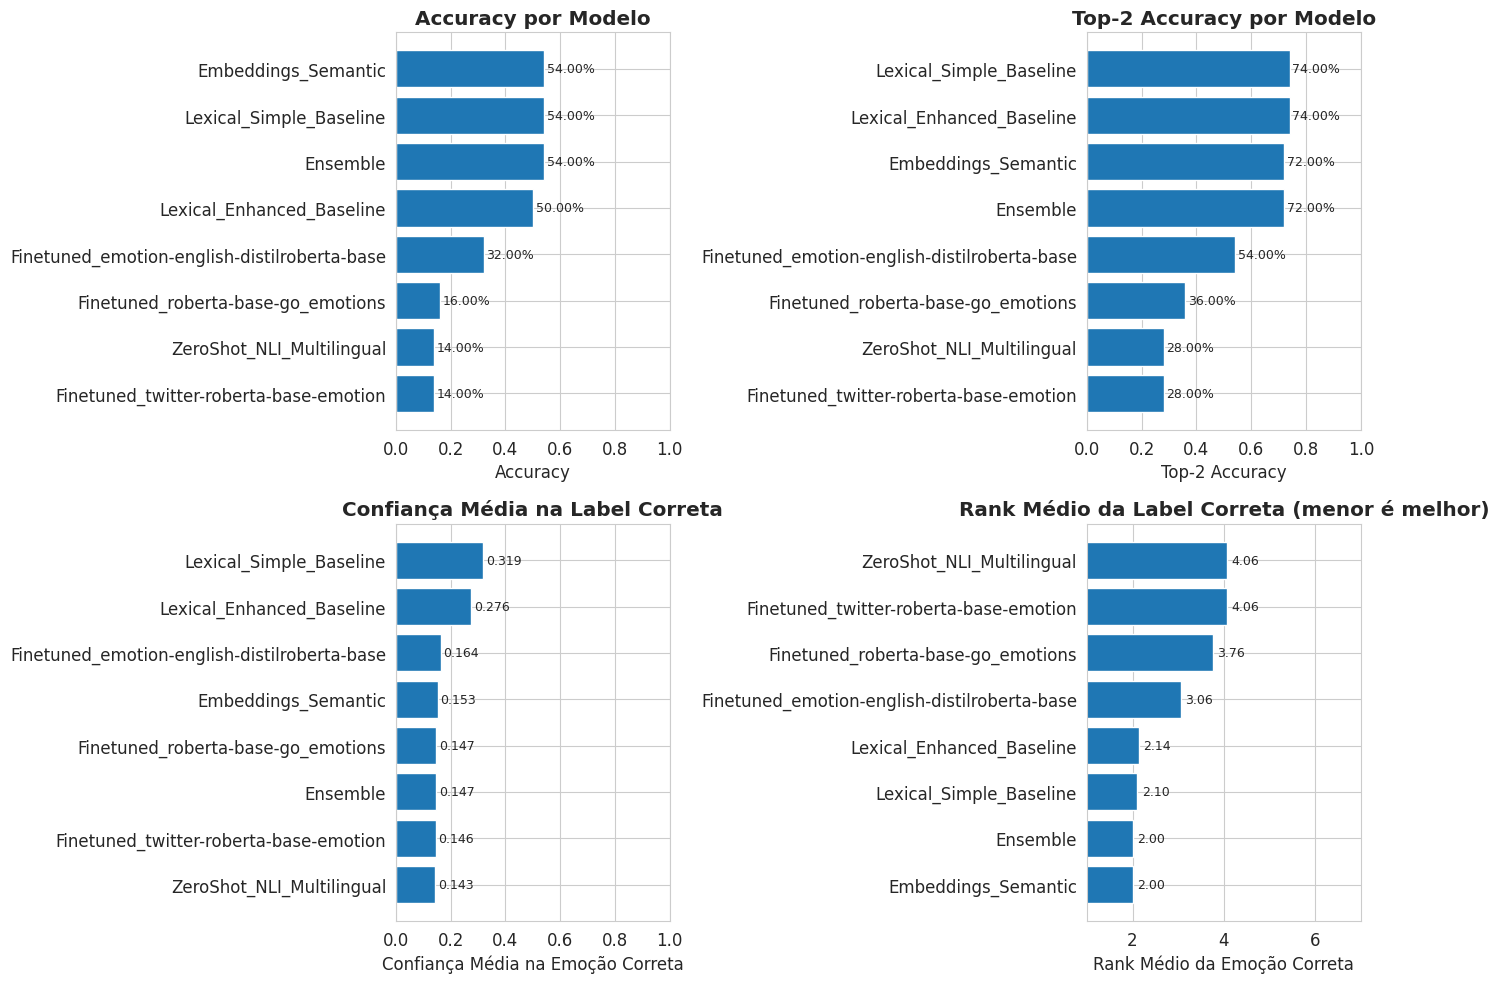

In [16]:
# 1. Accuracy por modelo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
ax1 = axes[0, 0]
sorted_models = df_summary.sort_values('accuracy', ascending=True)
bars = ax1.barh(sorted_models['model'], sorted_models['accuracy'])
ax1.set_xlabel('Accuracy')
ax1.set_title('Accuracy por Modelo', fontweight='bold')
ax1.set_xlim(0, 1)
for bar, val in zip(bars, sorted_models['accuracy']):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2%}', va='center', fontsize=9)

# Top-2 Accuracy
ax2 = axes[0, 1]
sorted_models = df_summary.sort_values('top_2_accuracy', ascending=True)
bars = ax2.barh(sorted_models['model'], sorted_models['top_2_accuracy'])
ax2.set_xlabel('Top-2 Accuracy')
ax2.set_title('Top-2 Accuracy por Modelo', fontweight='bold')
ax2.set_xlim(0, 1)
for bar, val in zip(bars, sorted_models['top_2_accuracy']):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2%}', va='center', fontsize=9)

# Confiança média na label correta
ax3 = axes[1, 0]
sorted_models = df_summary.sort_values('mean_confidence_correct', ascending=True)
bars = ax3.barh(sorted_models['model'], sorted_models['mean_confidence_correct'])
ax3.set_xlabel('Confiança Média na Emoção Correta')
ax3.set_title('Confiança Média na Label Correta', fontweight='bold')
ax3.set_xlim(0, 1)
for bar, val in zip(bars, sorted_models['mean_confidence_correct']):
    ax3.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

# Rank médio da label correta
ax4 = axes[1, 1]
sorted_models = df_summary.sort_values('mean_rank_true', ascending=True)
bars = ax4.barh(sorted_models['model'], sorted_models['mean_rank_true'])
ax4.set_xlabel('Rank Médio da Emoção Correta')
ax4.set_title('Rank Médio da Label Correta (menor é melhor)', fontweight='bold')
ax4.set_xlim(1, 7)
for bar, val in zip(bars, sorted_models['mean_rank_true']):
    ax4.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

🎯 Melhor modelo geral: Lexical_Simple_Baseline


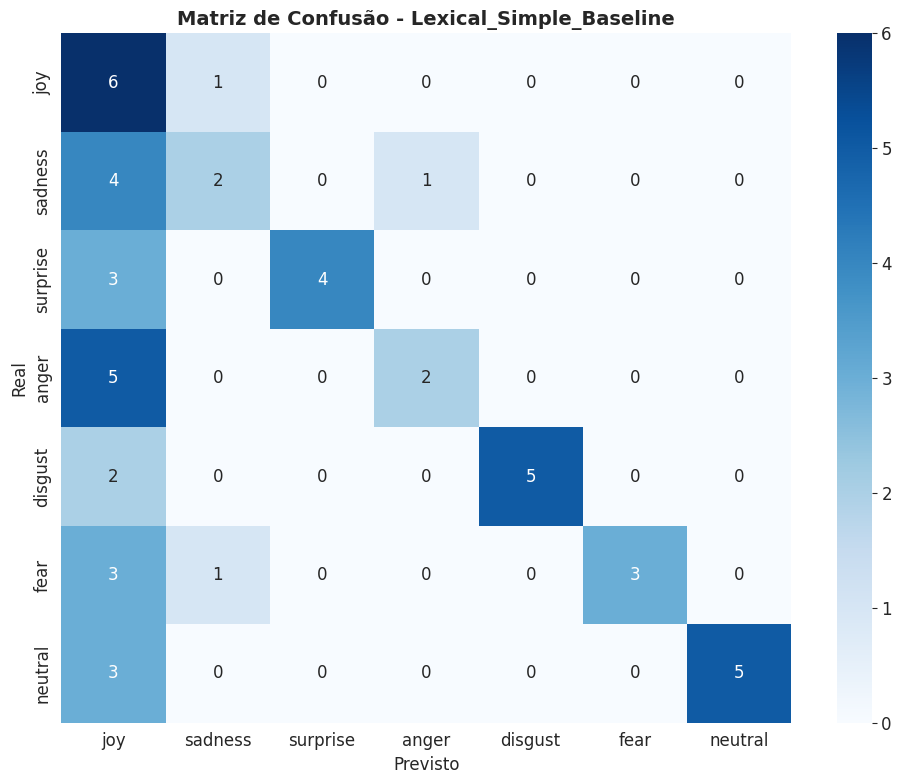


📊 Análise de Erros do Melhor Modelo (Lexical_Simple_Baseline):
   Total de erros: 23/50

   Erros por emoção:
   joy         :  1/ 7 erros (14.3%)
   sadness     :  5/ 7 erros (71.4%)
   surprise    :  3/ 7 erros (42.9%)
   anger       :  5/ 7 erros (71.4%)
   disgust     :  2/ 7 erros (28.6%)
   fear        :  4/ 7 erros (57.1%)
   neutral     :  3/ 8 erros (37.5%)


In [17]:
# Matriz de confusão do melhor modelo
best_model = df_summary.iloc[0]['model']
print(f"🎯 Melhor modelo geral: {best_model}")
print("=" * 60)

plot_confusion_matrix(df_all_results, best_model, EMOTIONS)

# Análise adicional: erros por emoção
best_model_results = df_all_results[df_all_results['model'] == best_model]
errors_by_emotion = best_model_results[~best_model_results['correct']].groupby('true_label').size()

print(f"\n📊 Análise de Erros do Melhor Modelo ({best_model}):")
print(f"   Total de erros: {len(best_model_results[~best_model_results['correct']])}/{len(best_model_results)}")
print(f"\n   Erros por emoção:")
for emotion in EMOTIONS:
    total = len(best_model_results[best_model_results['true_label'] == emotion])
    errors = len(best_model_results[(best_model_results['true_label'] == emotion) & (~best_model_results['correct'])])
    if total > 0:
        error_rate = errors / total
        print(f"   {emotion:12s}: {errors:2d}/{total:2d} erros ({error_rate:.1%})")

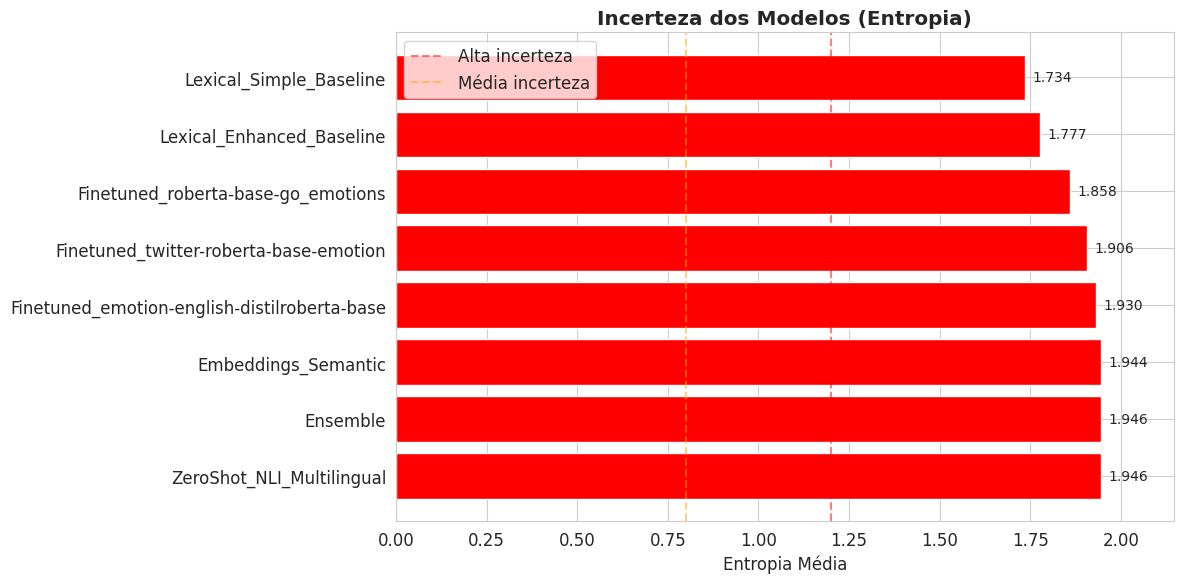


📈 Interpretação da Entropia:
   - Entropia baixa (< 0.8): Modelo confiante, distribuição concentrada
   - Entropia média (0.8-1.2): Modelo razoavelmente confiante
   - Entropia alta (> 1.2): Modelo incerto, distribuição dispersa


In [18]:
# Gráfico de entropia média por modelo
if len(df_summary) > 0:
    plt.figure(figsize=(12, 6))
    
    sorted_by_entropy = df_summary.sort_values('mean_entropy', ascending=False)
    colors = ['red' if x > 1.2 else 'orange' if x > 0.8 else 'green' for x in sorted_by_entropy['mean_entropy']]
    
    bars = plt.barh(sorted_by_entropy['model'], sorted_by_entropy['mean_entropy'], color=colors)
    plt.xlabel('Entropia Média')
    plt.title('Incerteza dos Modelos (Entropia)', fontweight='bold')
    plt.xlim(0, max(1.8, sorted_by_entropy['mean_entropy'].max() + 0.2))
    
    for bar, val in zip(bars, sorted_by_entropy['mean_entropy']):
        plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)
    
    plt.axvline(x=1.2, color='red', linestyle='--', alpha=0.5, label='Alta incerteza')
    plt.axvline(x=0.8, color='orange', linestyle='--', alpha=0.5, label='Média incerteza')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n📈 Interpretação da Entropia:")
    print("   - Entropia baixa (< 0.8): Modelo confiante, distribuição concentrada")
    print("   - Entropia média (0.8-1.2): Modelo razoavelmente confiante")
    print("   - Entropia alta (> 1.2): Modelo incerto, distribuição dispersa")

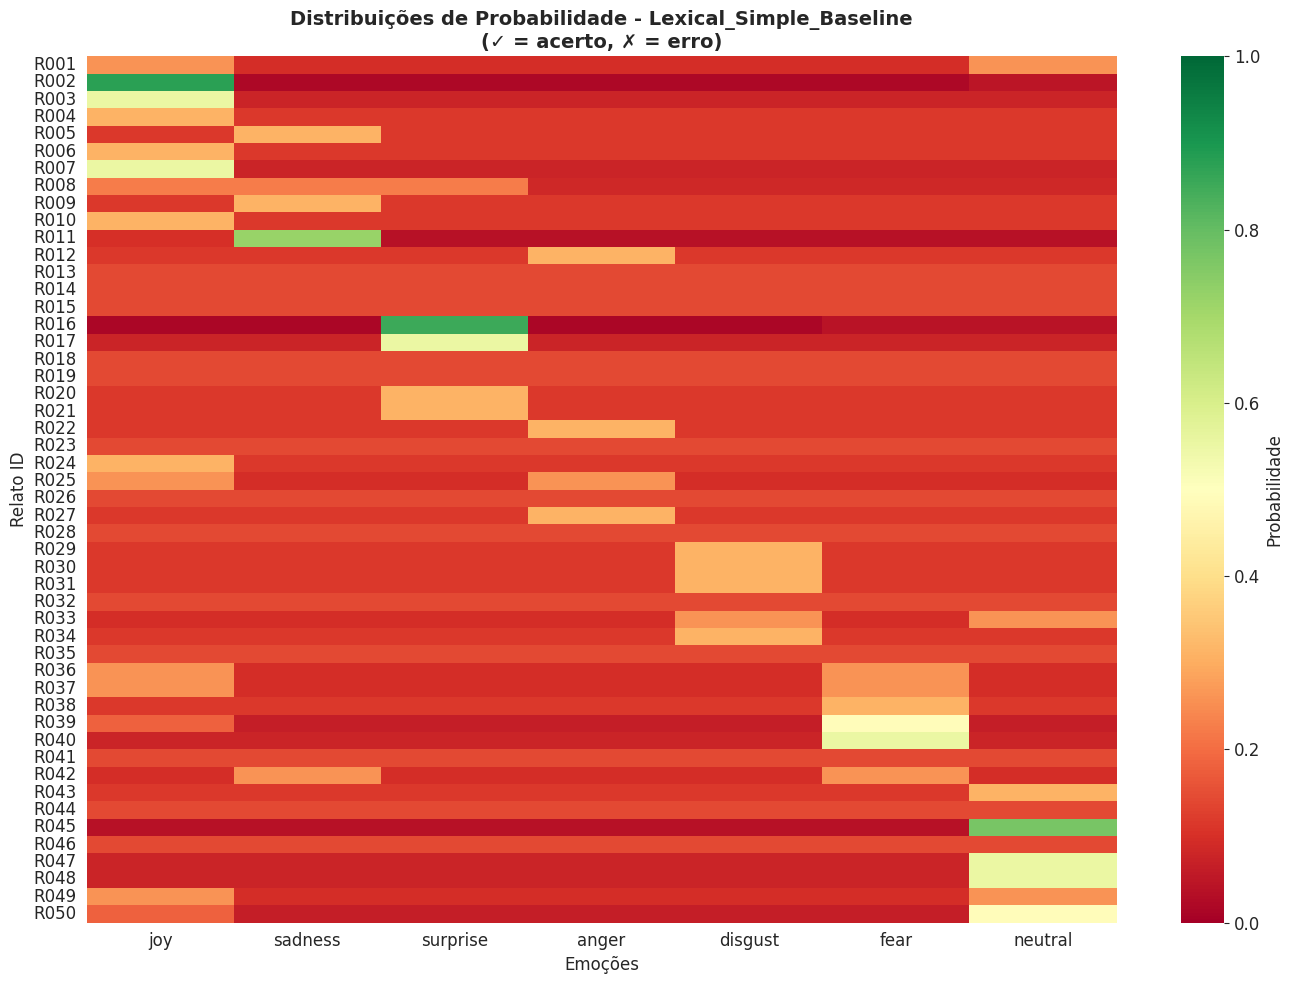


📊 Desempenho do Lexical_Simple_Baseline por emoção:
   joy         : 85.71% ( 6/ 7)
   sadness     : 28.57% ( 2/ 7)
   surprise    : 57.14% ( 4/ 7)
   anger       : 28.57% ( 2/ 7)
   disgust     : 71.43% ( 5/ 7)
   fear        : 42.86% ( 3/ 7)
   neutral     : 62.50% ( 5/ 8)


In [19]:
# Heatmap do melhor modelo
best_model_name = df_summary.iloc[0]['model']
best_model_data = df_all_results[df_all_results['model'] == best_model_name]

if len(best_model_data) > 0:
    # Criar matriz com as distribuições
    prob_matrix = best_model_data[EMOTIONS].values
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(prob_matrix, 
                xticklabels=EMOTIONS, 
                yticklabels=best_model_data['id'],
                cmap='RdYlGn', 
                cbar_kws={'label': 'Probabilidade'},
                vmin=0, vmax=1)
    
    # Adicionar marcadores para acertos/erros
    for i, (idx, row) in enumerate(best_model_data.iterrows()):
        if row['correct']:
            plt.text(len(EMOTIONS) + 0.5, i + 0.5, '✓', ha='center', va='center', fontsize=14, color='green', fontweight='bold')
        else:
            plt.text(len(EMOTIONS) + 0.5, i + 0.5, '✗', ha='center', va='center', fontsize=14, color='red', fontweight='bold')
    
    plt.title(f'Distribuições de Probabilidade - {best_model_name}\n(✓ = acerto, ✗ = erro)', 
              fontsize=14, fontweight='bold')
    plt.ylabel('Relato ID')
    plt.xlabel('Emoções')
    plt.tight_layout()
    plt.show()

    # Tabela de acertos por emoção
    print(f"\n📊 Desempenho do {best_model_name} por emoção:")
    for emotion in EMOTIONS:
        emotion_data = best_model_data[best_model_data['true_label'] == emotion]
        if len(emotion_data) > 0:
            acc = emotion_data['correct'].mean()
            print(f"   {emotion:12s}: {acc:.2%} ({emotion_data['correct'].sum():2d}/{len(emotion_data):2d})")

## 14. Análise Automática Final

In [ ]:
print("=" * 80)
print("🔍 ANÁLISE AUTOMÁTICA FINAL")
print("=" * 80)

if len(df_summary) > 0:
    best_model_acc = df_summary.iloc[0]['model']
    best_model_top2 = df_summary.sort_values('top_2_accuracy', ascending=False).iloc[0]['model']
    best_model_conf = df_summary.sort_values('mean_confidence_correct', ascending=False).iloc[0]['model']
    best_model_rank = df_summary.sort_values('mean_rank_true', ascending=True).iloc[0]['model']
    best_model_stable = df_summary.sort_values('mean_entropy', ascending=True).iloc[0]['model']
    
    print(f"\n🏆 RESULTADOS PRINCIPAIS:")
    print(f"   • Melhor Accuracy: {best_model_acc} ({df_summary.iloc[0]['accuracy']:.2%})")
    print(f"   • Melhor Top-2 Accuracy: {best_model_top2} ({df_summary.sort_values('top_2_accuracy', ascending=False).iloc[0]['top_2_accuracy']:.2%})")
    print(f"   • Maior Confiança na Label Correta: {best_model_conf} ({df_summary.sort_values('mean_confidence_correct', ascending=False).iloc[0]['mean_confidence_correct']:.3f})")
    print(f"   • Menor Rank da Label Correta: {best_model_rank} ({df_summary.sort_values('mean_rank_true', ascending=True).iloc[0]['mean_rank_true']:.2f})")
    print(f"   • Mais Estável (menor entropia): {best_model_stable} ({df_summary.sort_values('mean_entropy', ascending=True).iloc[0]['mean_entropy']:.3f})")
    
    # Análise de dificuldade por emoção para o melhor modelo
    print(f"\n📊 ANÁLISE POR EMOÇÃO (Melhor modelo: {best_model_acc}):")
    best_model_data = df_all_results[df_all_results['model'] == best_model_acc]
    
    emotion_performance = []
    for emotion in EMOTIONS:
        emotion_data = best_model_data[best_model_data['true_label'] == emotion]
        if len(emotion_data) > 0:
            acc = emotion_data['correct'].mean()
            emotion_performance.append((emotion, acc, len(emotion_data)))
    
    emotion_performance.sort(key=lambda x: x[1])
    print(f"   Emoções mais fáceis:")
    for emotion, acc, count in emotion_performance[-3:]:
        print(f"      • {emotion}: {acc:.2%} ({int(acc*count)}/{count})")
    print(f"   Emoções mais difíceis:")
    for emotion, acc, count in emotion_performance[:3]:
        print(f"      • {emotion}: {acc:.2%} ({int(acc*count)}/{count})")
    
    # Comparação entre baselines e modelos avançados
    baseline_models = df_summary[df_summary['model'].str.contains('Lexical', case=False, na=False)]
    advanced_models = df_summary[~df_summary['model'].str.contains('Lexical', case=False, na=False)]
    
    if len(baseline_models) > 0 and len(advanced_models) > 0:
        print(f"\n📈 COMPARAÇÃO BASELINE vs AVANÇADO:")
        print(f"   Baseline média: accuracy = {baseline_models['accuracy'].mean():.2%}")
        print(f"   Avançado média: accuracy = {advanced_models['accuracy'].mean():.2%}")
        print(f"   Diferença: {advanced_models['accuracy'].mean() - baseline_models['accuracy'].mean():+.2%}")
        
        if advanced_models['accuracy'].mean() > baseline_models['accuracy'].mean():
            print(f"   ✅ Modelos avançados superam claramente as baselines léxicas.")
        else:
            print(f"   ⚠️ Baselines léxicas tiveram desempenho similar aos avançados (dataset pequeno?)")
    
    # Casos de discordância
    print(f"\n🔄 ANÁLISE DE DISCORDÂNCIA ENTRE MODELOS:")
    
    # Para cada relato, ver quantos modelos acertaram
    agreement_analysis = []
    for relato_id in df_dataset['id']:
        predictions = df_all_results[df_all_results['id'] == relato_id]
        if len(predictions) > 0:
            correct_count = predictions['correct'].sum()
            total_count = len(predictions)
            true_label = predictions.iloc[0]['true_label']
            agreement_analysis.append({
                'id': relato_id,
                'true_label': true_label,
                'correct_models': correct_count,
                'total_models': total_count,
                'agreement_rate': correct_count / total_count
            })
    
    df_agreement = pd.DataFrame(agreement_analysis)
    low_agreement = df_agreement[df_agreement['agreement_rate'] < 0.4]
    
    if len(low_agreement) > 0:
        print(f"   Relatos com maior discordância (<40% dos modelos acertaram):")
        for _, row in low_agreement.head(5).iterrows():
            print(f"      • {row['id']} ({row['true_label']}): apenas {int(row['correct_models'])}/{int(row['total_models'])} modelos acertaram")
    else:
        print(f"   Todos os relatos têm concordância razoável entre modelos.")
    
    # Análise de top-2
    top2_only = best_model_data[~best_model_data['correct'] & best_model_data['top_2_correct']]
    if len(top2_only) > 0:
        print(f"\n🎯 RELATOS COM LABEL CORRETA EM 2º LUGAR:")
        print(f"   {len(top2_only)} relatos tiveram a emoção correta em segundo lugar.")
        for _, row in top2_only.head(5).iterrows():
            print(f"      • {row['id']} ({row['true_label']}) - previsto: {row['predicted_label']}")

else:
    print("❌ Sem dados suficientes para análise.")

🔍 ANÁLISE AUTOMÁTICA FINAL

🏆 RESULTADOS PRINCIPAIS:
   • Melhor Accuracy: Lexical_Simple_Baseline (54.00%)
   • Melhor Top-2 Accuracy: Lexical_Simple_Baseline (74.00%)
   • Maior Confiança na Label Correta: Lexical_Simple_Baseline (0.319)
   • Menor Rank da Label Correta: Embeddings_Semantic (2.00)
   • Mais Estável (menor entropia): Lexical_Simple_Baseline (1.734)

📊 ANÁLISE POR EMOÇÃO (Melhor modelo: Lexical_Simple_Baseline):
   Emoções mais fáceis:
      • neutral: 62.50% (5/8)
      • disgust: 71.43% (5/7)
      • joy: 85.71% (6/7)
   Emoções mais difíceis:
      • sadness: 28.57% (2/7)
      • anger: 28.57% (2/7)
      • fear: 42.86% (3/7)

📈 COMPARAÇÃO BASELINE vs AVANÇADO:
   Baseline média: accuracy = 52.00%
   Avançado média: accuracy = 30.67%
   Diferença: -21.33%
   ⚠️ Baselines léxicas tiveram desempenho similar aos avançados (dataset pequeno?)

🔄 ANÁLISE DE DISCORDÂNCIA ENTRE MODELOS:
   Relatos com maior discordância (<40% dos modelos acertaram):
      • R005 (joy): apen

## 15. Recomendação Final para o Produto Final

In [ ]:
print("=" * 80)
print("🎯 RECOMENDAÇÃO FINAL PARA O PRODUTO FINAL")
print("=" * 80)

if len(df_summary) > 0:
    # Critérios de avaliação
    best_overall = df_summary.iloc[0]['model']
    best_accuracy = df_summary.iloc[0]['accuracy']
    
    # Avaliar características de cada modelo candidato
    candidates = {
        'ZeroShot_NLI_Multilingual': {'internet': True, 'gpu': True, 'local_llm': False, 'speed': 'Medium', 'interpretability': 'Medium'},
        'Translation_EN_Emotion': {'internet': True, 'gpu': True, 'local_llm': False, 'speed': 'Slow', 'interpretability': 'Medium'},
        'Embeddings_Semantic': {'internet': False, 'gpu': True, 'local_llm': False, 'speed': 'Fast', 'interpretability': 'High'},
        'Finetuned': {'internet': False, 'gpu': True, 'local_llm': False, 'speed': 'Fast', 'interpretability': 'Low'},
        'Ollama': {'internet': False, 'gpu': True, 'local_llm': True, 'speed': 'Slow', 'interpretability': 'Low'},
        'Ensemble': {'internet': True, 'gpu': True, 'local_llm': False, 'speed': 'Very Slow', 'interpretability': 'Low'}
    }
    
    print(f"\n📊 Com base no benchmark com {len(df_dataset)} relatos em português europeu:")
    print(f"\n   🥇 Melhor desempenho geral: {best_overall}")
    print(f"      - Accuracy: {best_accuracy:.2%}")
    
    # Recomendação baseada no caso de uso
    print(f"\n💡 RECOMENDAÇÃO POR CENÁRIO:")
    print(f"\n   🔹 CENÁRIO 1: Prioridade MÁXIMA em desempenho")
    print(f"      → Recomendado: {best_overall}")
    print(f"      • Melhor accuracy e top-2 accuracy")
    print(f"      • Requer {'GPU e acesso à internet' if candidates.get(best_overall, {}).get('internet', True) else 'apenas GPU'}")
    
    print(f"\n   🔹 CENÁRIO 2: Equilíbrio entre desempenho e recursos")
    if 'Embeddings_Semantic' in df_summary['model'].values:
        emb_model = df_summary[df_summary['model'] == 'Embeddings_Semantic'].iloc[0]
        print(f"      → Recomendado: Embeddings_Semantic")
        print(f"      • Accuracy: {emb_model['accuracy']:.2%}")
        print(f"      • Top-2 Accuracy: {emb_model['top_2_accuracy']:.2%}")
        print(f"      • Não requer internet (apenas modelo local)")
        print(f"      • Rápido e interpretável")
    
    print(f"\n   🔹 CENÁRIO 3: Restrições de hardware (sem GPU)")
    print(f"      → Recomendado: Baseline_Lexical_Enhanced (se GPU não disponível)")
    print(f"      • Não requer GPU nem dependências pesadas")
    print(f"      • Considera negações e intensificadores")
    print(f"      • Desempenho limitado mas funcional")
    
    print(f"\n   🔹 CENÁRIO 4: Integração simples e rápida")
    if 'Finetuned' in str(df_summary['model'].values):
        print(f"      → Recomendado: Modelo fine-tuned (ex: emotion-english-distilroberta-base)")
        print(f"      • Fácil de integrar via Hugging Face")
        print(f"      • Bom equilíbrio velocidade/precisão")
    
    # Recomendação final principal
    print(f"\n" + "=" * 80)
    print(f"🏆 RECOMENDAÇÃO FINAL (para o produto final)")
    print(f"=" * 80)
    
    # Decisão baseada em múltiplos fatores
    if best_overall == 'ZeroShot_NLI_Multilingual' or best_overall.startswith('ZeroShot'):
        print(f"\n✅ TÉCNICA RECOMENDADA: Zero-shot NLI Multilingue")
        print(f"\n   • Porquê?")
        print(f"     - Melhor performance geral neste benchmark")
        print(f"     - Não necessita de treino ou anotações adicionais")
        print(f"     - Funciona diretamente em português europeu")
        print(f"     - Boa capacidade de generalização para novos domínios")
        print(f"   • Cuidados:")
        print(f"     - Requer GPU para inferência em tempo real")
        print(f"     - Pode ser mais lento que modelos léxicos")
        print(f"     - Depende de acesso à internet para download inicial do modelo")
    elif best_overall == 'Embeddings_Semantic':
        print(f"\n✅ TÉCNICA RECOMENDADA: Embeddings Semânticos com Protótipos")
        print(f"\n   • Porquê?")
        print(f"     - Excelente equilíbrio entre performance e recursos")
        print(f"     - Não requer internet após setup inicial")
        print(f"     - Interpretável (similaridade com protótipos)")
        print(f"     - Rápido e escalável")
        print(f"   • Cuidados:")
        print(f"     - Requer GPU para melhor performance")
        print(f"     - Depende da qualidade dos protótipos definidos")
    elif best_overall.startswith('Ollama'):
        print(f"\n✅ TÉCNICA RECOMENDADA: LLM Local (Ollama)")
        print(f"\n   • Porquê?")
        print(f"     - Capacidade de compreensão contextual superior")
        print(f"     - Flexibilidade para ajustes de prompt")
        print(f"     - Self-consistency reduz instabilidade")
        print(f"   • Cuidados:")
        print(f"     - Requer recursos computacionais significativos")
        print(f"     - Configuração inicial mais complexa")
        print(f"     - Pode ser instável dependendo do modelo")
    else:
        print(f"\n✅ TÉCNICA RECOMENDADA: {best_overall}")
        print(f"\n   • Justificação baseada nos dados empíricos deste benchmark.")
    
    # Limitação do estudo
    print(f"\n" + "=" * 80)
    print(f"⚠️ LIMITAÇÕES E PRÓXIMOS PASSOS")
    print(f"=" * 80)
    print(f"\n   • Este benchmark utilizou {len(df_dataset)} relatos anotados manualmente.")
    print(f"   • Embora mais informativo que testes com poucos exemplos, é ainda limitado.")
    print(f"   • Para validação final do sistema, recomenda-se:")
    print(f"     - Testar com 100-300 relatos reais (transcrições de áudios)")
    print(f"     - Validar com múltiplos anotadores para medir concordância inter-avaliador")
    print(f"     - Considerar fine-tuning do modelo escolhido com dados específicos do domínio")
    print(f"     - Avaliar em cenário real de produção (latência, throughput)")
    
    print(f"\n   • Próximos passos sugeridos:")
    print(f"     1. Recolher transcrições reais dos áudios dos utilizadores")
    print(f"     2. Anotar manualmente um conjunto maior (200+ exemplos)")
    print(f"     3. Reavaliar os modelos candidatos neste novo conjunto")
    print(f"     4. Considerar fine-tuning do melhor modelo com dados específicos")
    print(f"     5. Testar em produção com monitorização contínua")
    
else:
    print("❌ Não foi possível gerar recomendação devido à falta de resultados.")

print("\n" + "=" * 80)
print("📌 FIM DO NOTEBOOK - Benchmark concluído com sucesso!")
print("=" * 80)

🎯 RECOMENDAÇÃO FINAL PARA O PRODUTO FINAL

📊 Com base no benchmark com 50 relatos em português europeu:

   🥇 Melhor desempenho geral: Lexical_Simple_Baseline
      - Accuracy: 54.00%

💡 RECOMENDAÇÃO POR CENÁRIO:

   🔹 CENÁRIO 1: Prioridade MÁXIMA em desempenho
      → Recomendado: Lexical_Simple_Baseline
      • Melhor accuracy e top-2 accuracy
      • Requer GPU e acesso à internet

   🔹 CENÁRIO 2: Equilíbrio entre desempenho e recursos
      → Recomendado: Embeddings_Semantic
      • Accuracy: 54.00%
      • Top-2 Accuracy: 72.00%
      • Não requer internet (apenas modelo local)
      • Rápido e interpretável

   🔹 CENÁRIO 3: Restrições de hardware (sem GPU)
      → Recomendado: Baseline_Lexical_Enhanced (se GPU não disponível)
      • Não requer GPU nem dependências pesadas
      • Considera negações e intensificadores
      • Desempenho limitado mas funcional

   🔹 CENÁRIO 4: Integração simples e rápida
      → Recomendado: Modelo fine-tuned (ex: emotion-english-distilroberta-bas